# Per-Group TARP Calibration — DiffDock

Investigates DiffDock's calibration **separately** for each of its three diffusion groups:
- **Translation** (R³): where does the ligand centroid land?
- **Rotation** (SO(3)): how is the ligand oriented?
- **Torsion** (T^k): what are the internal dihedral angles?

Uses TARP (Lemos et al., ICML 2023): ECP(α) vs α curves, where perfect calibration = diagonal,
curve below diagonal = overconfident (posterior too narrow), above = underconfident.

Data computed by `analysis/run_group_eval.py` submitted via `~/slurm/diffdock_group_eval.sh`.

## 0 · Setup

In [1]:
import sys, os, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

from molcalib.tarp import ecp_from_fractions, plot_ecp, bootstrap_ecp

# ── Paths ─────────────────────────────────────────────────────────────────────
PDB_METRICS   = "/home/qf226/rds/hpc-work/results/DiffDock/pdbbind_testset/metrics"
PDB_GE        = os.path.join(PDB_METRICS, "group_eval")
PB_METRICS    = "/home/qf226/rds/hpc-work/results/DiffDock/pb_evaluate_v2_merged/metrics"
PB_GE         = os.path.join(PB_METRICS, "group_eval")
FIGURES       = "/home/qf226/MProject/thesis/figures/group_tarp_mira"
os.makedirs(FIGURES, exist_ok=True)

# ── Group constants ────────────────────────────────────────────────────────────
GROUPS  = ['translation', 'rotation', 'torsion']
COLORS  = {'translation': 'C0', 'rotation': 'C1', 'torsion': 'C2'}
LABELS  = {'translation': 'Translation (R³)', 'rotation': 'Rotation (SO(3))', 'torsion': 'Torsion (T^k)'}
UNITS   = {'translation': 'Å', 'rotation': 'rad', 'torsion': 'rad (RMS)'}

# dist_keys uses the torsion_rms key (distances array) vs torsion (TARP array)
dist_keys   = ['translation', 'rotation', 'torsion_rms']
dist_labels = {
    'translation': 'Translation (Å)',
    'rotation':    'Rotation (rad)',
    'torsion_rms': 'Torsion RMS (rad)',
}

def load_npy(path, allow_pickle=False):
    """Load .npy returning None if file doesn't exist."""
    if os.path.exists(path):
        return np.load(path, allow_pickle=allow_pickle)
    print(f'  [missing] {path}')
    return None

print('Setup complete.')

Setup complete.


## 1 · Load Data

In [2]:
# ── PDBBind group eval outputs ─────────────────────────────────────────────────
pdb_names_tarp = load_npy(f'{PDB_GE}/complex_names.npy', allow_pickle=True)
pdb_names_dist = load_npy(f'{PDB_GE}/complex_names_distances.npy', allow_pickle=True)
pdb_nrot       = load_npy(f'{PDB_GE}/n_rot_bonds.npy')
pdb_nrot_tarp  = load_npy(f'{PDB_GE}/n_rot_bonds_tarp.npy')

pdb_tarp = {}
pdb_dist = {}
for g in GROUPS:
    pdb_tarp[g] = load_npy(f'{PDB_GE}/tarp_fractions_{g}.npy')
for g in ['translation', 'rotation', 'torsion_rms']:
    pdb_dist[g] = load_npy(f'{PDB_GE}/distances_{g}.npy')

# ── PoseBusters group eval outputs ────────────────────────────────────────────
pb_names_tarp = load_npy(f'{PB_GE}/complex_names.npy', allow_pickle=True)
pb_names_dist = load_npy(f'{PB_GE}/complex_names_distances.npy', allow_pickle=True)
pb_nrot       = load_npy(f'{PB_GE}/n_rot_bonds.npy')
pb_nrot_tarp  = load_npy(f'{PB_GE}/n_rot_bonds_tarp.npy')

pb_tarp = {}
pb_dist = {}
for g in GROUPS:
    pb_tarp[g] = load_npy(f'{PB_GE}/tarp_fractions_{g}.npy')
for g in ['translation', 'rotation', 'torsion_rms']:
    pb_dist[g] = load_npy(f'{PB_GE}/distances_{g}.npy')

# ── Existing aggregated metrics (PDBBind) ─────────────────────────────────────
pdb_top1_rmsd  = load_npy(f'{PDB_METRICS}/top1_rmsd.npy')
pdb_all_names  = load_npy(f'{PDB_METRICS}/complex_names.npy', allow_pickle=True)

# ── PoseBusters validity results (PDBBind set) ────────────────────────────────
import json
_pb_path = f'{PDB_METRICS}/posebusters_results.json'
pb_validity = json.load(open(_pb_path)) if os.path.exists(_pb_path) else {}

print(f'PDBBind  TARP: {pdb_names_tarp is not None and len(pdb_names_tarp)} complexes')
print(f'PDBBind  dist: {pdb_names_dist is not None and len(pdb_names_dist)} complexes')
print(f'PoseBusters TARP: {pb_names_tarp is not None and len(pb_names_tarp)} complexes')
print(f'PoseBusters dist: {pb_names_dist is not None and len(pb_names_dist)} complexes')

PDBBind  TARP: 322 complexes
PDBBind  dist: 322 complexes
PoseBusters TARP: 305 complexes
PoseBusters dist: 305 complexes


## 2 · Per-Group TARP ECP Curves

TARP (Tests of Accuracy with Random Points, Lemos et al. 2023):
- For each complex, draw K random reference points from the prior, compute distances to the crystal and all samples
- f(reference, complex) = fraction of samples closer to crystal than the reference
- ECP(α) = fraction of complexes where f ≤ α
- Perfect calibration: ECP = α (diagonal). Below diagonal = overconfident. Above = underconfident.

**Prior distributions used:**
- Translation: N(Cα COM, σ²I) where σ = std_ca × 1.46 / 1.73 (DiffDock's prior at t=1)
- Rotation: Haar-uniform on SO(3) (random unit quaternion)
- Torsion: Uniform([-π, π])^k

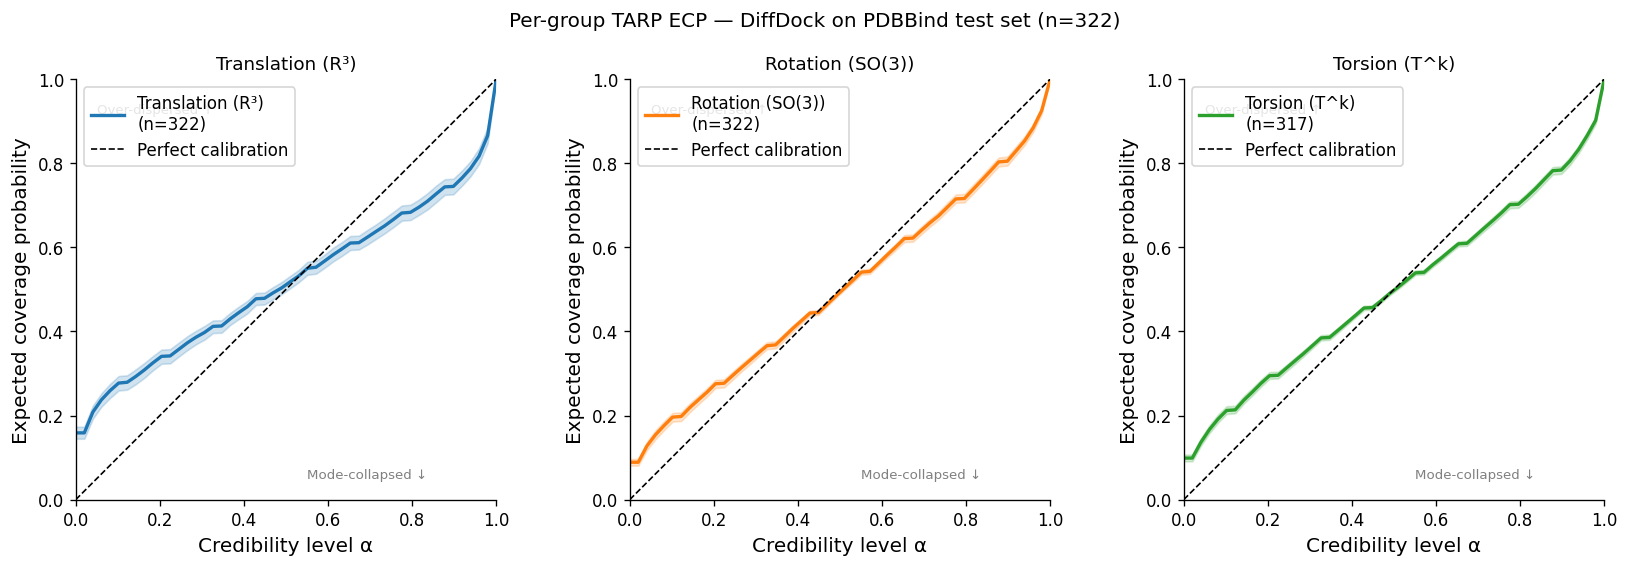

In [3]:
# 2a: Three-panel ECP — PDBBind
if pdb_names_tarp is not None and all(pdb_tarp[g] is not None for g in GROUPS):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    for ax, g in zip(axes, GROUPS):
        f = pdb_tarp[g]
        ecp, alpha = ecp_from_fractions(f)
        boot = bootstrap_ecp(f, n_bootstrap=500)
        n_valid = np.sum(np.any(np.isfinite(f), axis=1))
        plot_ecp(ecp, alpha, ax=ax, label=f'{LABELS[g]}\n(n={n_valid})', color=COLORS[g], bootstrap_ecps=boot)
        ax.set_title(LABELS[g], fontsize=11)
    fig.suptitle('Per-group TARP ECP — DiffDock on PDBBind test set (n=322)', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/group_tarp_ecp_pdbbind.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('PDBBind group TARP data not yet available — run group_eval job first.')

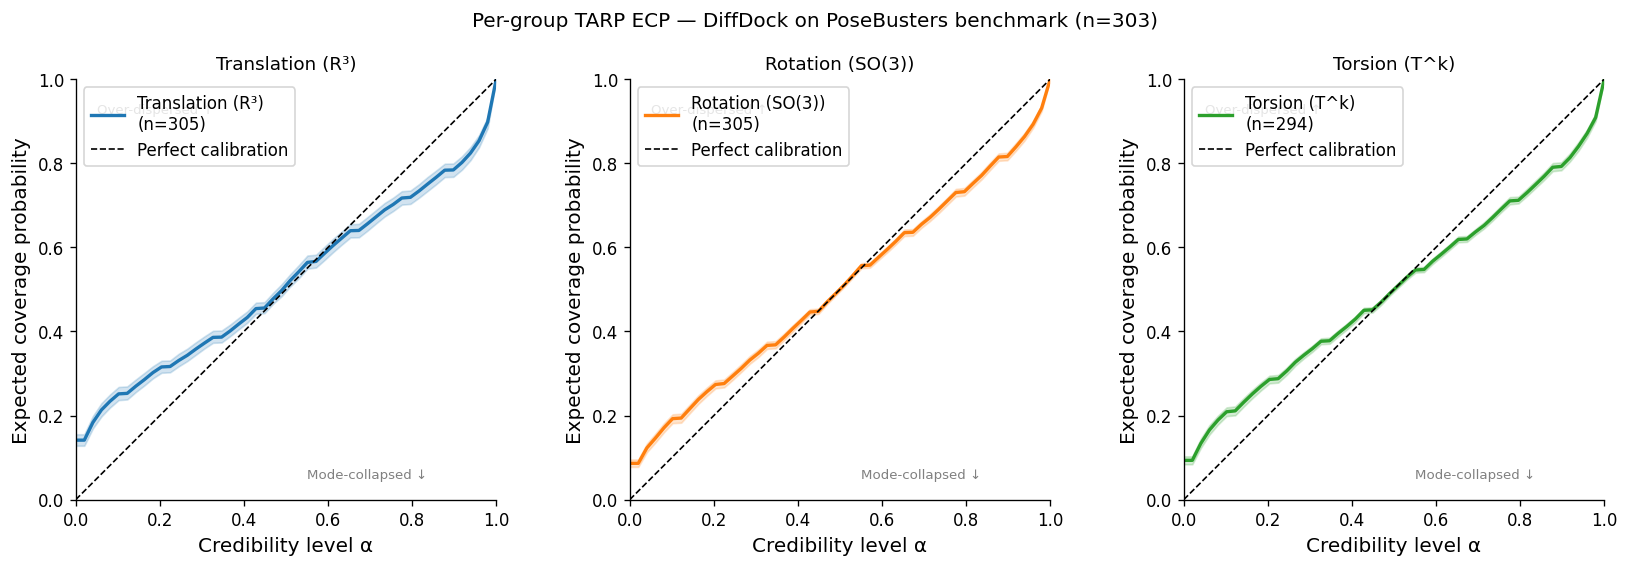

In [4]:
# 2b: Three-panel ECP — PoseBusters
if pb_names_tarp is not None and all(pb_tarp[g] is not None for g in GROUPS):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    for ax, g in zip(axes, GROUPS):
        f = pb_tarp[g]
        ecp, alpha = ecp_from_fractions(f)
        boot = bootstrap_ecp(f, n_bootstrap=500)
        n_valid = np.sum(np.any(np.isfinite(f), axis=1))
        plot_ecp(ecp, alpha, ax=ax, label=f'{LABELS[g]}\n(n={n_valid})', color=COLORS[g], bootstrap_ecps=boot)
        ax.set_title(LABELS[g], fontsize=11)
    fig.suptitle('Per-group TARP ECP — DiffDock on PoseBusters benchmark (n=303)', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/group_tarp_ecp_posebusters.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('PoseBusters group TARP data not yet available.')

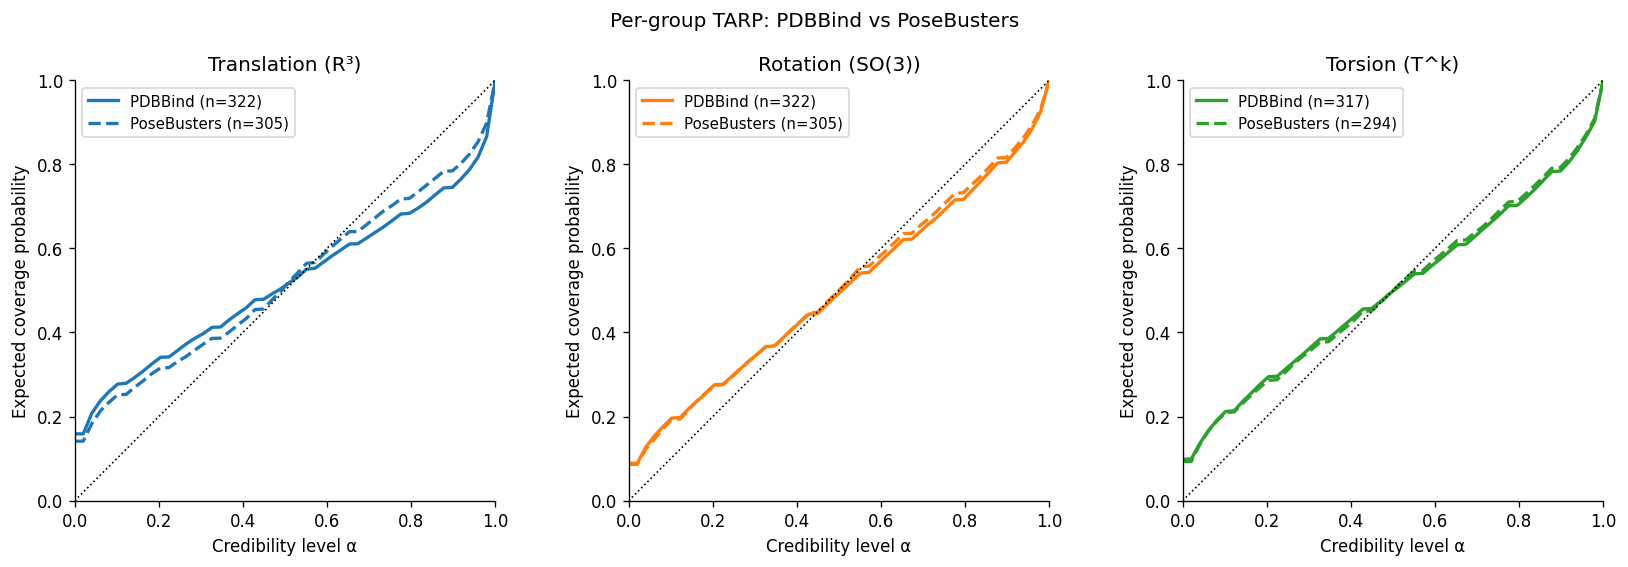

In [5]:
# 2c: Cross-dataset overlay — one panel per group, PDBBind vs PoseBusters
datasets_ready = (
    pdb_names_tarp is not None and all(pdb_tarp[g] is not None for g in GROUPS) and
    pb_names_tarp is not None  and all(pb_tarp[g] is not None for g in GROUPS)
)
if datasets_ready:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    for ax, g in zip(axes, GROUPS):
        for ds_name, f, ls in [('PDBBind', pdb_tarp[g], '-'), ('PoseBusters', pb_tarp[g], '--')]:
            ecp, alpha = ecp_from_fractions(f)
            n_valid = np.sum(np.any(np.isfinite(f), axis=1))
            ax.plot(alpha, ecp, ls=ls, color=COLORS[g], lw=2, label=f'{ds_name} (n={n_valid})')
        ax.plot([0, 1], [0, 1], 'k:', lw=1)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
        ax.set_xlabel('Credibility level α')
        ax.set_ylabel('Expected coverage probability')
        ax.set_title(LABELS[g])
        ax.legend(fontsize=9)
    fig.suptitle('Per-group TARP: PDBBind vs PoseBusters', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/group_tarp_ecp_overlay.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Need both datasets to produce overlay — data not yet available.')

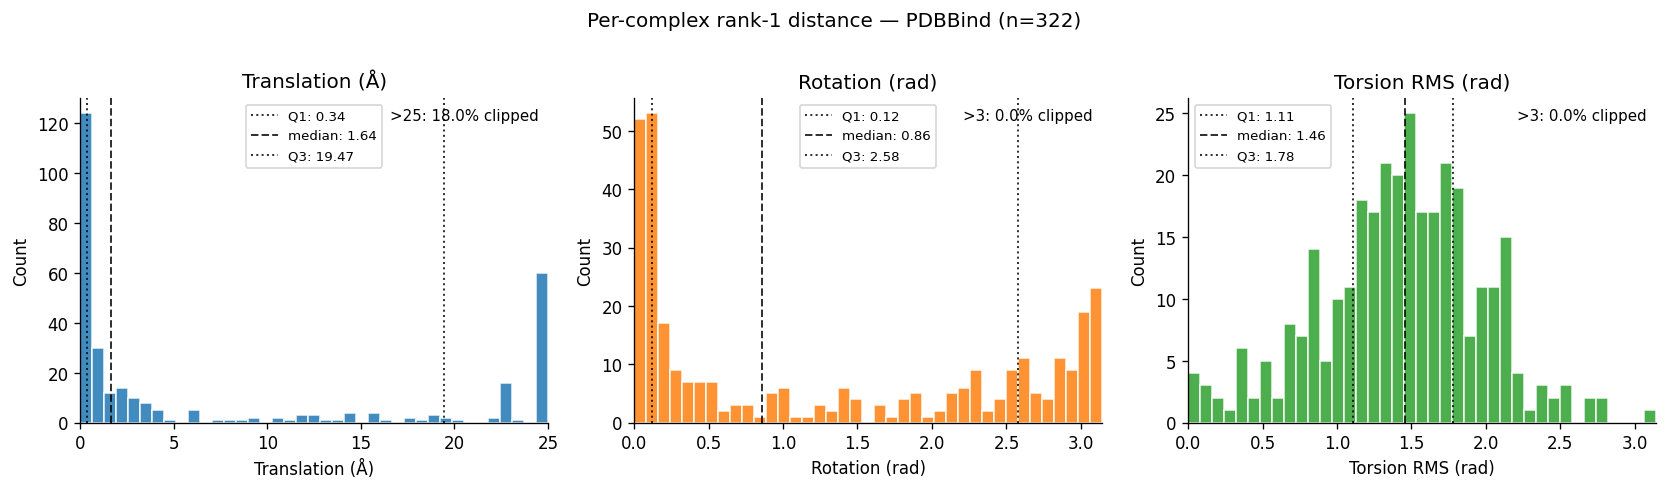

In [6]:
# 2d: Per-complex rank-1 distance — distribution across complexes per group
if pdb_names_dist is not None and all(pdb_dist[k] is not None for k in dist_keys):
    xlims_2d = {'translation': 25.0, 'rotation': np.pi, 'torsion_rms': np.pi}
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, key in zip(axes, dist_keys):
        D     = pdb_dist[key]
        rank1 = D[:, 0]
        xlim  = xlims_2d[key]
        finite = rank1[np.isfinite(rank1)]
        col   = COLORS['torsion'] if key == 'torsion_rms' else COLORS[key]
        ax.hist(np.clip(finite, 0, xlim), bins=np.linspace(0, xlim, 40),
                color=col, edgecolor='white', alpha=0.85)
        for pct, ls, lbl in [(25, ':', 'Q1'), (50, '--', 'median'), (75, ':', 'Q3')]:
            v = float(np.nanpercentile(finite, pct))
            ax.axvline(min(v, xlim), color='k', ls=ls, lw=1.2, alpha=0.8,
                       label=f'{lbl}: {v:.2f}')
        ax.set_xlim(0, xlim)
        ax.set_xlabel(dist_labels[key])
        ax.set_ylabel('Count')
        ax.set_title(dist_labels[key])
        ax.legend(fontsize=8)
        pct_clipped = (finite > xlim).mean() * 100
        ax.text(0.98, 0.97, f'>{xlim:.0f}: {pct_clipped:.1f}% clipped',
                transform=ax.transAxes, ha='right', va='top', fontsize=9)
    fig.suptitle('Per-complex rank-1 distance — PDBBind (n=322)', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/group_rank1_dist_per_complex_pdbbind.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Distance data not yet available.')

## 2.5 · Per-Group MIRA Scores

MIRA (Sharief et al. 2026, arXiv:2605.02014) is a scalar calibration metric.
For each complex T random centers are drawn from the group's prior; for each
center a random reference sample determines the ball radius; the score is
whether the crystal lies inside the same ball as the other samples.

**Null reference (perfect calibration):** `mira_null(S) = (2/3) × (S+1)/S ≈ 0.683` for S = 40.
Score **above** null → over-dispersed. Score **below** null → mode-collapsed.

Per-group priors (match DiffDock's randomize_position at t = 1):
- **Translation:** N(Cα_COM, σ²I)
- **Rotation:** Haar-uniform SO(3)
- **Torsion:** Uniform([-π, π])^k per rotatable bond

Run once via `python analysis/run_group_mira.py ...`, or compute here and cache automatically.

In [7]:
# 2.5a: Load per-group MIRA scores from cache, or compute and cache now.
#
# To compute via SLURM instead, run:
#   python analysis/run_group_mira.py \
#       --complex_names_npy <complex_names.npy> \
#       --results_dir <poses_dir> --data_dir /home/qf226/rds/hpc-work/data/PDBBind_processed \
#       --out_dir <group_eval_dir> --num_runs 100 --n_workers 8

from eval_diffdock.group_mira_runner import run_group_mira_eval
from molcalib.mira import mira_null as _mira_null, bootstrap_mira
from eval_diffdock.loader import build_results_index

MIRA_NUM_RUNS = 100
MIRA_NULL_40  = _mira_null(S=40)

# ── PDBBind ──────────────────────────────────────────────────────────────────
pdb_group_mira = {}
_need_compute_pdb = False

for _g in ('translation', 'rotation', 'torsion'):
    _sc = f'{PDB_GE}/mira_scores_{_g}.npy'
    _nm = f'{PDB_GE}/mira_names_{_g}.npy'
    if os.path.exists(_sc) and os.path.exists(_nm):
        pdb_group_mira[_g] = {
            'names':  np.load(_nm, allow_pickle=True),
            'scores': np.load(_sc),
        }
        print(f"PDBBind  {_g:12s}: loaded {len(pdb_group_mira[_g]['scores'])} scores from cache")
    else:
        print(f"PDBBind  {_g:12s}: cache missing → will compute")
        _need_compute_pdb = True

if _need_compute_pdb and pdb_names_tarp is not None:
    print("\nComputing PDBBind per-group MIRA (this takes a few minutes) …")
    from pathlib import Path
    chunks = sorted(Path('/home/qf226/rds/hpc-work/results/DiffDock/pdbbind_testset/poses').glob('chunk_*'))
    if chunks:
        _pdb_idx = build_results_index('/home/qf226/rds/hpc-work/results/DiffDock/pdbbind_testset/poses')
    else:
        _pdb_idx = {d.name: d for d in Path('/home/qf226/rds/hpc-work/results/DiffDock/pdbbind_testset/poses').iterdir() if d.is_dir()}

    _pdb_res = run_group_mira_eval(
        pdb_names_tarp, _pdb_idx, '/home/qf226/rds/hpc-work/data/PDBBind_processed',
        num_runs=MIRA_NUM_RUNS, seed=42, verbose=True, n_workers=4,
    )
    for _g in ('translation', 'rotation', 'torsion'):
        _nm_arr, _sc_arr = _pdb_res[_g]
        np.save(f'{PDB_GE}/mira_names_{_g}.npy', _nm_arr)
        np.save(f'{PDB_GE}/mira_scores_{_g}.npy', _sc_arr)
        pdb_group_mira[_g] = {'names': _nm_arr, 'scores': _sc_arr}
        print(f"  Saved {_g}: {len(_sc_arr)} scores → {PDB_GE}/mira_scores_{_g}.npy")

# ── PoseBusters ───────────────────────────────────────────────────────────────
pb_group_mira = {}
_need_compute_pb = False

for _g in ('translation', 'rotation', 'torsion'):
    _sc = f'{PB_GE}/mira_scores_{_g}.npy'
    _nm = f'{PB_GE}/mira_names_{_g}.npy'
    if os.path.exists(_sc) and os.path.exists(_nm):
        pb_group_mira[_g] = {
            'names':  np.load(_nm, allow_pickle=True),
            'scores': np.load(_sc),
        }
        print(f"PoseBusters {_g:12s}: loaded {len(pb_group_mira[_g]['scores'])} scores from cache")
    else:
        print(f"PoseBusters {_g:12s}: cache missing → will compute")
        _need_compute_pb = True

if _need_compute_pb and pb_names_tarp is not None:
    print("\nComputing PoseBusters per-group MIRA …")
    from pathlib import Path
    _pb_idx = {d.name: d for d in Path('/home/qf226/rds/hpc-work/results/DiffDock/pb_evaluate_v2_merged').iterdir() if d.is_dir() and any(d.glob('rank*.sdf'))}

    _pb_res = run_group_mira_eval(
        pb_names_tarp, _pb_idx, '/home/qf226/rds/hpc-work/data/posebusters_benchmark_set',
        num_runs=MIRA_NUM_RUNS, seed=42, verbose=True, n_workers=4,
    )
    for _g in ('translation', 'rotation', 'torsion'):
        _nm_arr, _sc_arr = _pb_res[_g]
        np.save(f'{PB_GE}/mira_names_{_g}.npy', _nm_arr)
        np.save(f'{PB_GE}/mira_scores_{_g}.npy', _sc_arr)
        pb_group_mira[_g] = {'names': _nm_arr, 'scores': _sc_arr}
        print(f"  Saved {_g}: {len(_sc_arr)} scores → {PB_GE}/mira_scores_{_g}.npy")

print(f"\nNull reference (S=40): {MIRA_NULL_40:.4f}")

PDBBind  translation : loaded 322 scores from cache
PDBBind  rotation    : loaded 322 scores from cache


PDBBind  torsion     : loaded 317 scores from cache
PoseBusters translation : loaded 305 scores from cache
PoseBusters rotation    : loaded 305 scores from cache
PoseBusters torsion     : loaded 294 scores from cache

Null reference (S=40): 0.6833


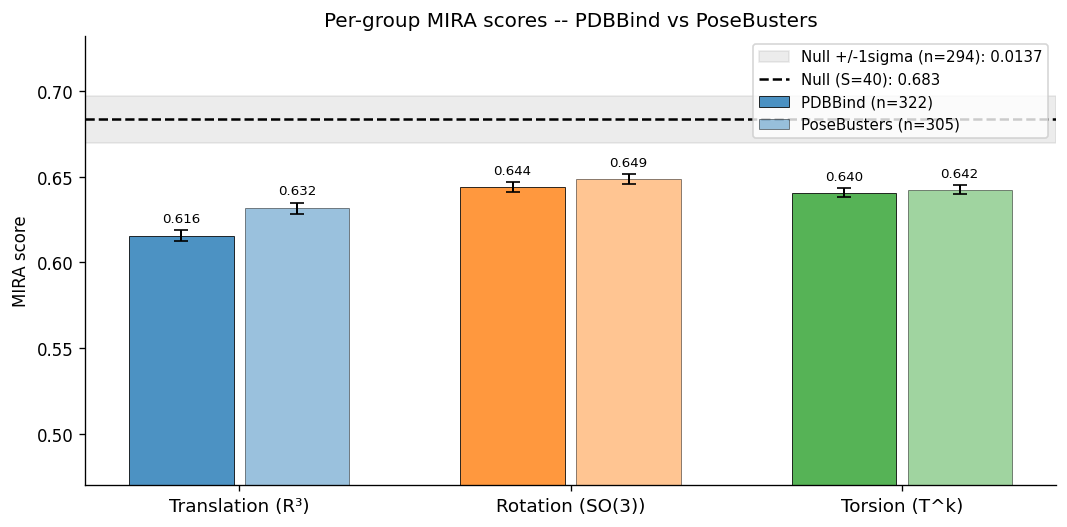

Group                          PDBBind      PoseBusters   dev (PDB)   1-sigma   sig?
------------------------------------------------------------------------------------
Translation (R³)        0.6156 (n=322)   0.6315 (n=305)     -0.0677    0.0131      *
Rotation (SO(3))        0.6439 (n=322)   0.6485 (n=305)     -0.0394    0.0131      *
Torsion (T^k)           0.6405 (n=317)   0.6423 (n=294)     -0.0429    0.0132      *
(null = 0.6833; * = |deviation from null| > 1-sigma)


In [8]:
# 2.5b: MIRA score bar chart -- PDBBind vs PoseBusters, one bar per group
if pdb_group_mira and pb_group_mira:
    _groups = ["translation", "rotation", "torsion"]
    _labels = [LABELS[g] for g in _groups]
    _x = np.arange(len(_groups))
    _width = 0.35

    fig, ax = plt.subplots(figsize=(9, 4.5))

    for i, g in enumerate(_groups):
        col = COLORS[g]
        for j, (ds_name, gm, ls) in enumerate([
            ("PDBBind",     pdb_group_mira, -_width / 2),
            ("PoseBusters", pb_group_mira,   _width / 2),
        ]):
            s = gm.get(g, {}).get("scores")
            if s is None or len(s) == 0:
                continue
            m = s.mean()
            se = bootstrap_mira(s)['std']
            ax.bar(_x[i] + ls, m, width=_width * 0.9,
                   color=col, alpha=0.8 if j == 0 else 0.45,
                   edgecolor="k", linewidth=0.6,
                   label=f"{ds_name} (n={len(s)})" if i == 0 else None)
            ax.errorbar(_x[i] + ls, m, yerr=se, fmt="none",
                        color="k", capsize=4, lw=1.2)
            ax.text(_x[i] + ls, m + se + 0.003, f"{m:.3f}",
                    ha="center", va="bottom", fontsize=8)

    # Analytic +-1sigma null band: sigma = sqrt(1/(18*L)), from Beta(2,1) null (MIRA paper)
    # Use the smallest valid L across groups and datasets (widest / most conservative band).
    _all_L = [
        (0 if gm.get(g, {}).get("scores") is None else len(gm.get(g, {}).get("scores")))
        for gm in (pdb_group_mira, pb_group_mira) for g in _groups
        if (0 if gm.get(g, {}).get("scores") is None else len(gm.get(g, {}).get("scores"))) > 0
    ]
    _L_ref = min(_all_L) if _all_L else 1
    _sigma = np.sqrt(1 / (18 * _L_ref))
    ax.axhspan(MIRA_NULL_40 - _sigma, MIRA_NULL_40 + _sigma,
               alpha=0.15, color="grey",
               label=f"Null +/-1sigma (n={_L_ref}): {_sigma:.4f}")
    ax.axhline(MIRA_NULL_40, color="k", ls="--", lw=1.5,
               label=f"Null (S=40): {MIRA_NULL_40:.3f}")

    ax.set_xticks(_x)
    ax.set_xticklabels(_labels, fontsize=11)
    ax.set_ylabel("MIRA score")
    ax.set_title("Per-group MIRA scores -- PDBBind vs PoseBusters", fontsize=12)
    ax.legend(fontsize=9)
    ax.set_ylim(0.47)
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/group_mira_scores_bar.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Summary table with per-group analytic sigma
    print("{:<22} {:>15}  {:>15}  {:>10}  {:>8}  {:>5}".format(
        "Group", "PDBBind", "PoseBusters", "dev (PDB)", "1-sigma", "sig?"))
    print("-" * 84)
    for g in _groups:
        pdb_s = pdb_group_mira.get(g, {}).get("scores")
        pb_s  = pb_group_mira.get(g, {}).get("scores")
        pdb_str = f"{pdb_s.mean():.4f} (n={len(pdb_s)})" if pdb_s is not None and len(pdb_s) else "(missing)"
        pb_str  = f"{pb_s.mean():.4f} (n={len(pb_s)})"  if pb_s  is not None and len(pb_s)  else "(missing)"
        L_g     = len(pdb_s) if pdb_s is not None and len(pdb_s) else 0
        sigma_g = np.sqrt(1 / (18 * L_g)) if L_g > 0 else float("nan")
        dev     = pdb_s.mean() - MIRA_NULL_40 if L_g > 0 else float("nan")
        dev_str   = f"{dev:+.4f}" if np.isfinite(dev) else ""
        sigma_str = f"{sigma_g:.4f}" if np.isfinite(sigma_g) else ""
        sig_flag  = "*" if np.isfinite(dev) and np.isfinite(sigma_g) and abs(dev) > sigma_g else ""
        print(f"{LABELS[g]:<22} {pdb_str:>15}  {pb_str:>15}  {dev_str:>10}  {sigma_str:>8}  {sig_flag:>5}")
    print(f"(null = {MIRA_NULL_40:.4f}; * = |deviation from null| > 1-sigma)")
else:
    print("MIRA scores not yet available -- run cell 2.5a first.")

## 3 · Per-Group Distance Distributions

Raw distances from crystal pose for all S=40 DiffDock samples per complex.
- **Translation**: L2 distance between centroids (Å)
- **Rotation**: geodesic angle on SO(3) = arccos((tr(R)-1)/2) (rad)
- **Torsion**: RMS of wrapped angular differences (rad)

Distances are symmetry-corrected via spyrmsd before extracting rotation/torsion.

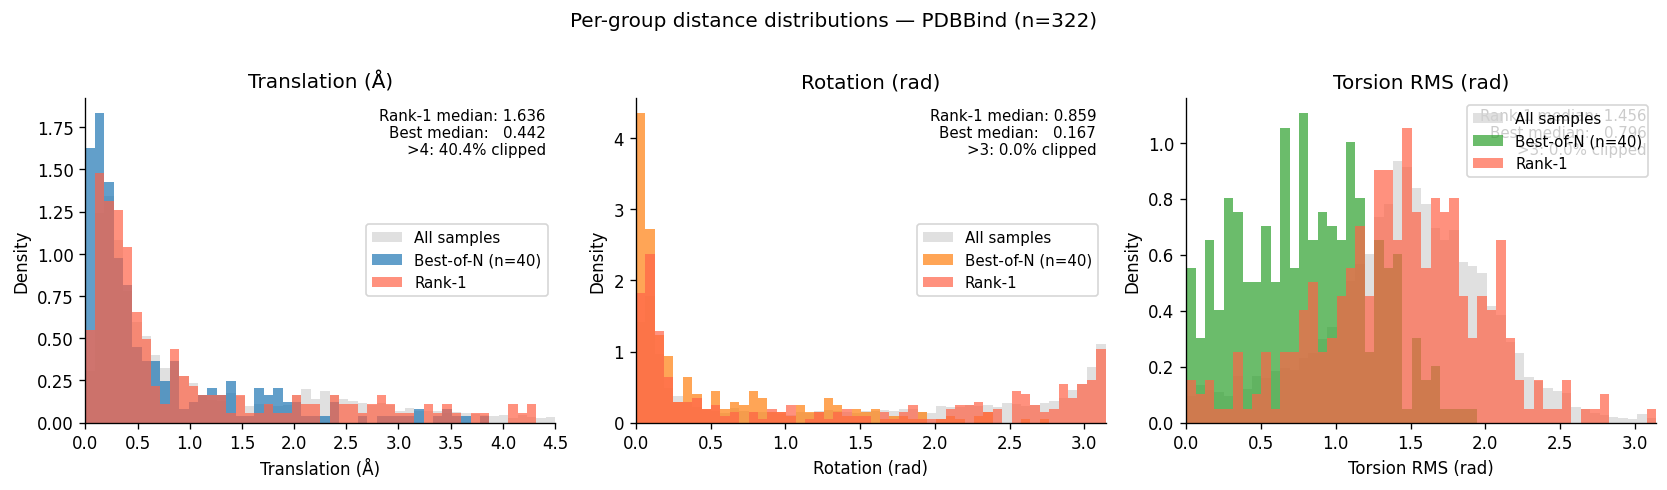

In [9]:
# 3a: Distance distributions — histograms of best-of-N vs rank-1 vs all samples
dist_xlims = {'translation': 4.5, 'rotation': np.pi, 'torsion_rms': np.pi}

if pdb_names_dist is not None and all(pdb_dist[k] is not None for k in dist_keys):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, key in zip(axes, dist_keys):
        D    = pdb_dist[key]  # (N, S)
        xlim = dist_xlims[key]
        rank1 = D[:, 0]
        best  = np.nanmin(D, axis=1)
        flat  = D.flatten()
        flat  = flat[np.isfinite(flat)]
        bins  = np.linspace(0, xlim, 51)
        ax.hist(flat,  bins=bins, color='lightgray', density=True, label='All samples', alpha=0.7)
        ax.hist(best,  bins=bins, color=COLORS['torsion'] if key == 'torsion_rms' else COLORS[key],
                density=True, alpha=0.7, label=f'Best-of-N (n={D.shape[1]})')
        ax.hist(rank1, bins=bins, color='tomato', density=True, alpha=0.7, label='Rank-1')
        ax.set_xlim(0, xlim)
        ax.set_xlabel(dist_labels[key])
        ax.set_ylabel('Density')
        ax.set_title(dist_labels[key])
        ax.legend(fontsize=9)
        pct_clipped = (flat > xlim).mean() * 100
        ax.text(0.98, 0.97,
                f'Rank-1 median: {np.nanmedian(rank1):.3f}\n'
                f'Best median:   {np.nanmedian(best):.3f}\n'
                f'>{xlim:.0f}: {pct_clipped:.1f}% clipped',
                transform=ax.transAxes, ha='right', va='top', fontsize=9)
    fig.suptitle('Per-group distance distributions — PDBBind (n=322)', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/group_distances_hist_pdbbind.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('PDBBind group distance data not yet available.')

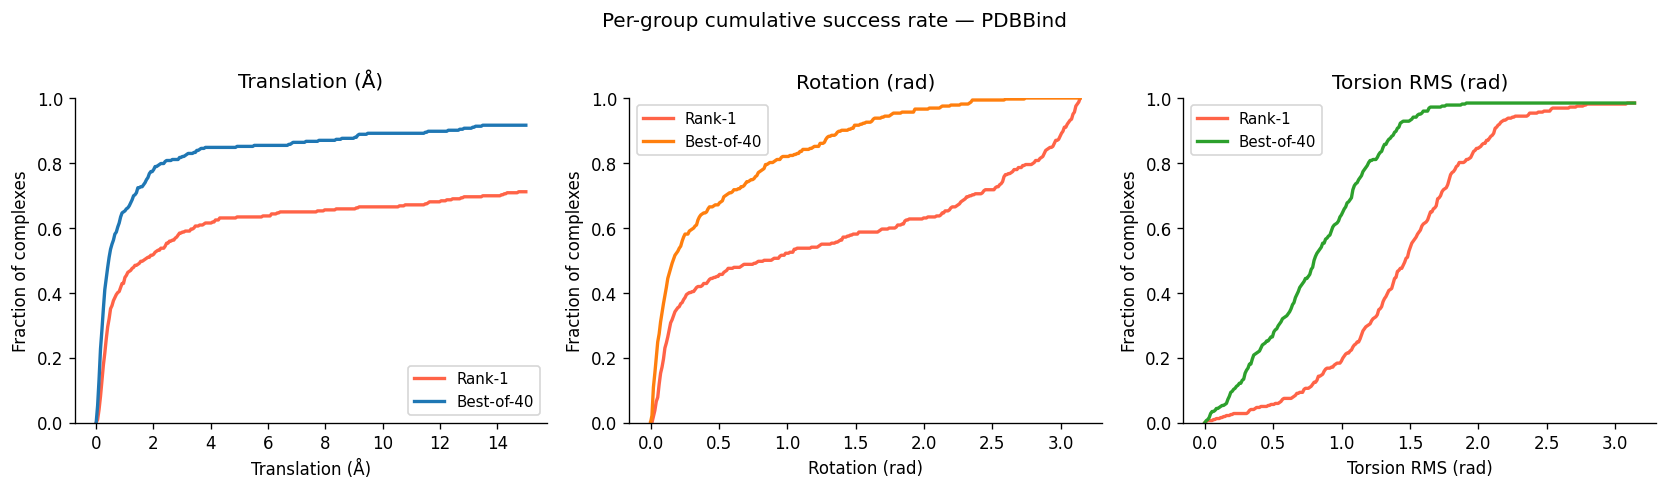

In [10]:
# 3b: Best-of-N success rate curves (analogous to RMSD < 2Å but for each group)
if pdb_names_dist is not None and all(pdb_dist[k] is not None for k in dist_keys):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    thresholds = {
        'translation': np.linspace(0, 15, 300),
        'rotation':    np.linspace(0, np.pi, 300),
        'torsion_rms': np.linspace(0, np.pi, 300),
    }
    for ax, key in zip(axes, dist_keys):
        D = pdb_dist[key]
        rank1 = D[:, 0]
        best  = np.nanmin(D, axis=1)
        ts = thresholds[key]
        cdf_rank1 = [(np.isfinite(rank1) & (rank1 < t)).mean() for t in ts]
        cdf_best  = [(np.isfinite(best)  & (best  < t)).mean() for t in ts]
        ax.plot(ts, cdf_rank1, color='tomato',    lw=2, label='Rank-1')
        ax.plot(ts, cdf_best,  color=COLORS['torsion'] if key == 'torsion_rms' else COLORS[key],
                lw=2, label=f'Best-of-{D.shape[1]}')
        ax.set_xlabel(dist_labels[key])
        ax.set_ylabel('Fraction of complexes')
        ax.set_title(dist_labels[key])
        ax.set_ylim(0, 1); ax.legend(fontsize=9)
    fig.suptitle('Per-group cumulative success rate — PDBBind', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/group_success_rate_pdbbind.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('PDBBind group distance data not yet available.')

## 4 · Stratification by Ligand Flexibility

Group complexes by number of rotatable bonds:
- Rigid: 0–2 bonds
- Low: 3–5 bonds
- Medium: 6–9 bonds
- Flexible: ≥10 bonds

Key question: does DiffDock's torsion calibration degrade with more flexible ligands?

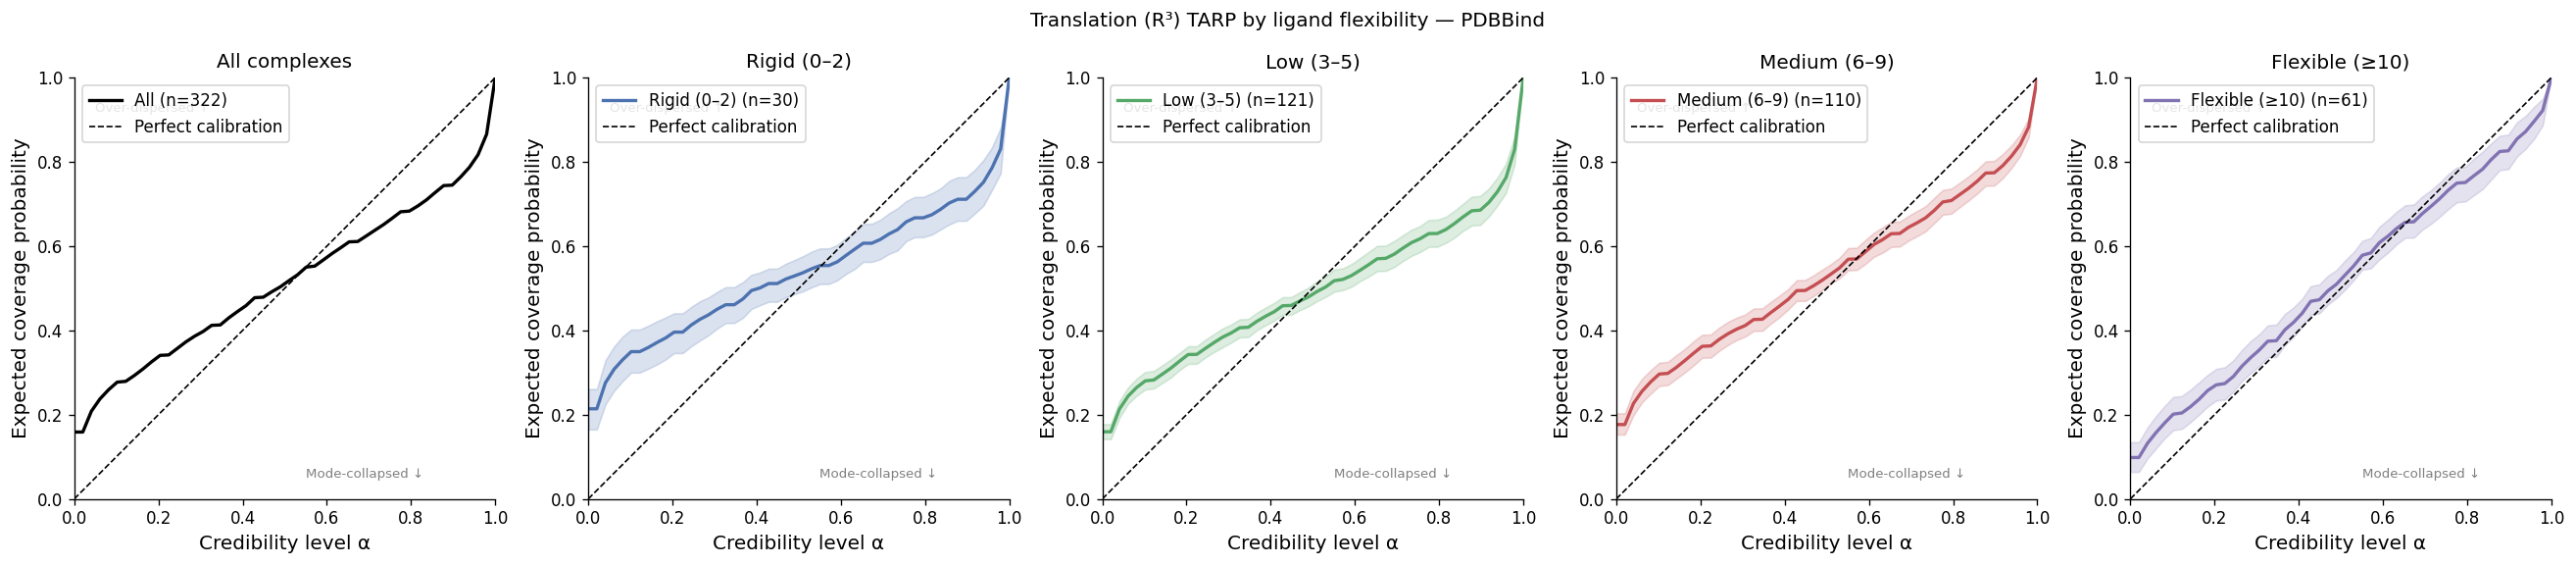

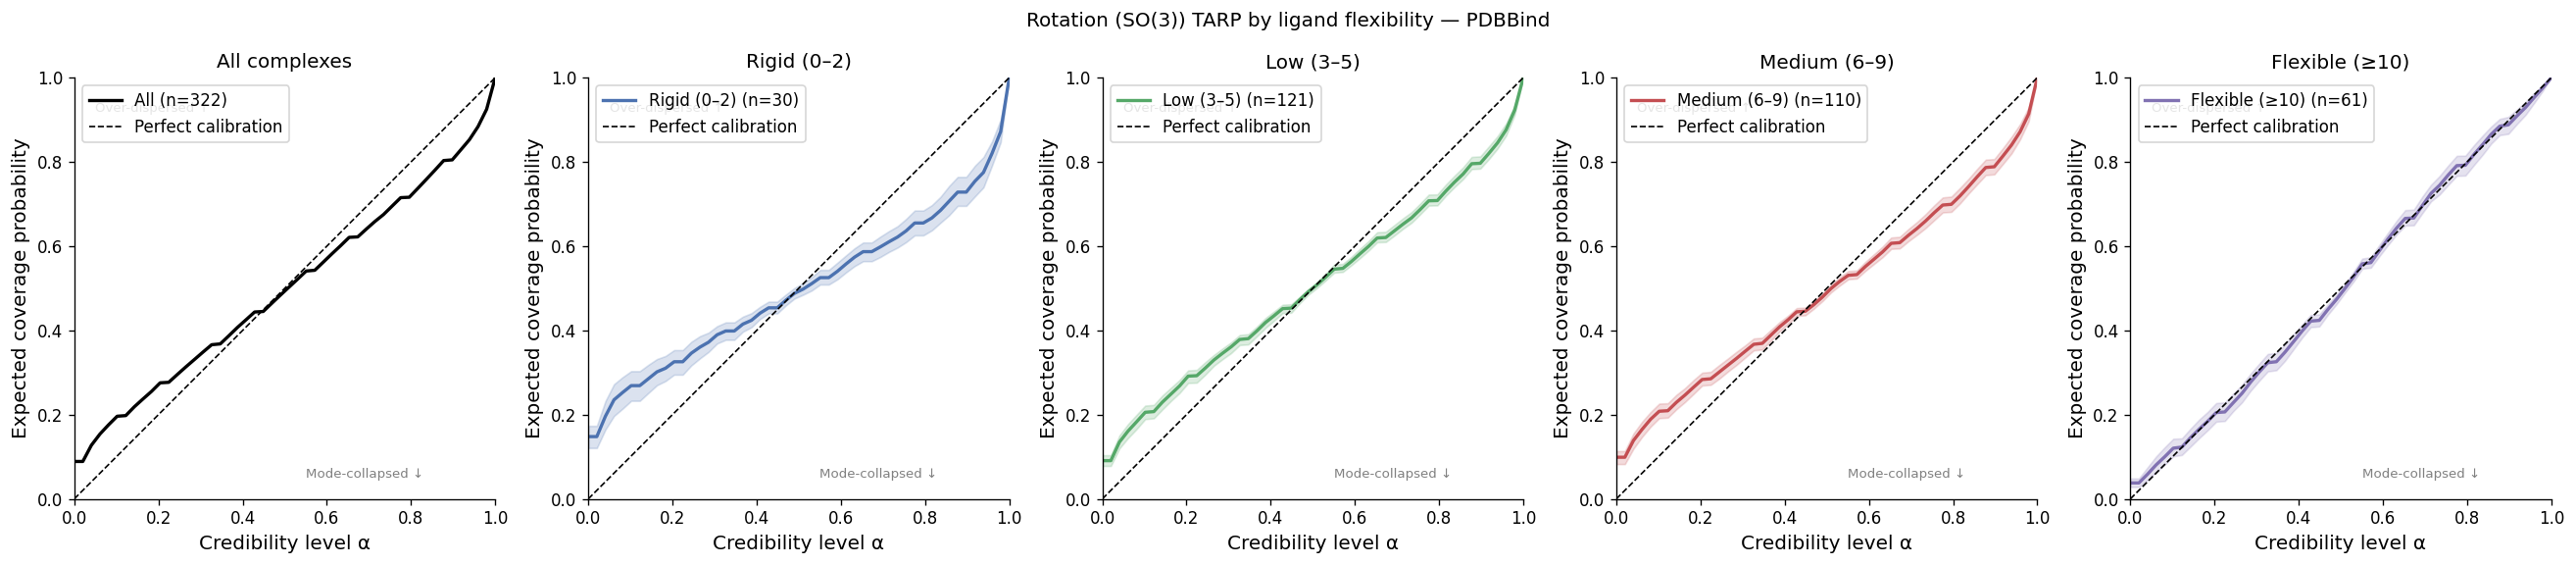

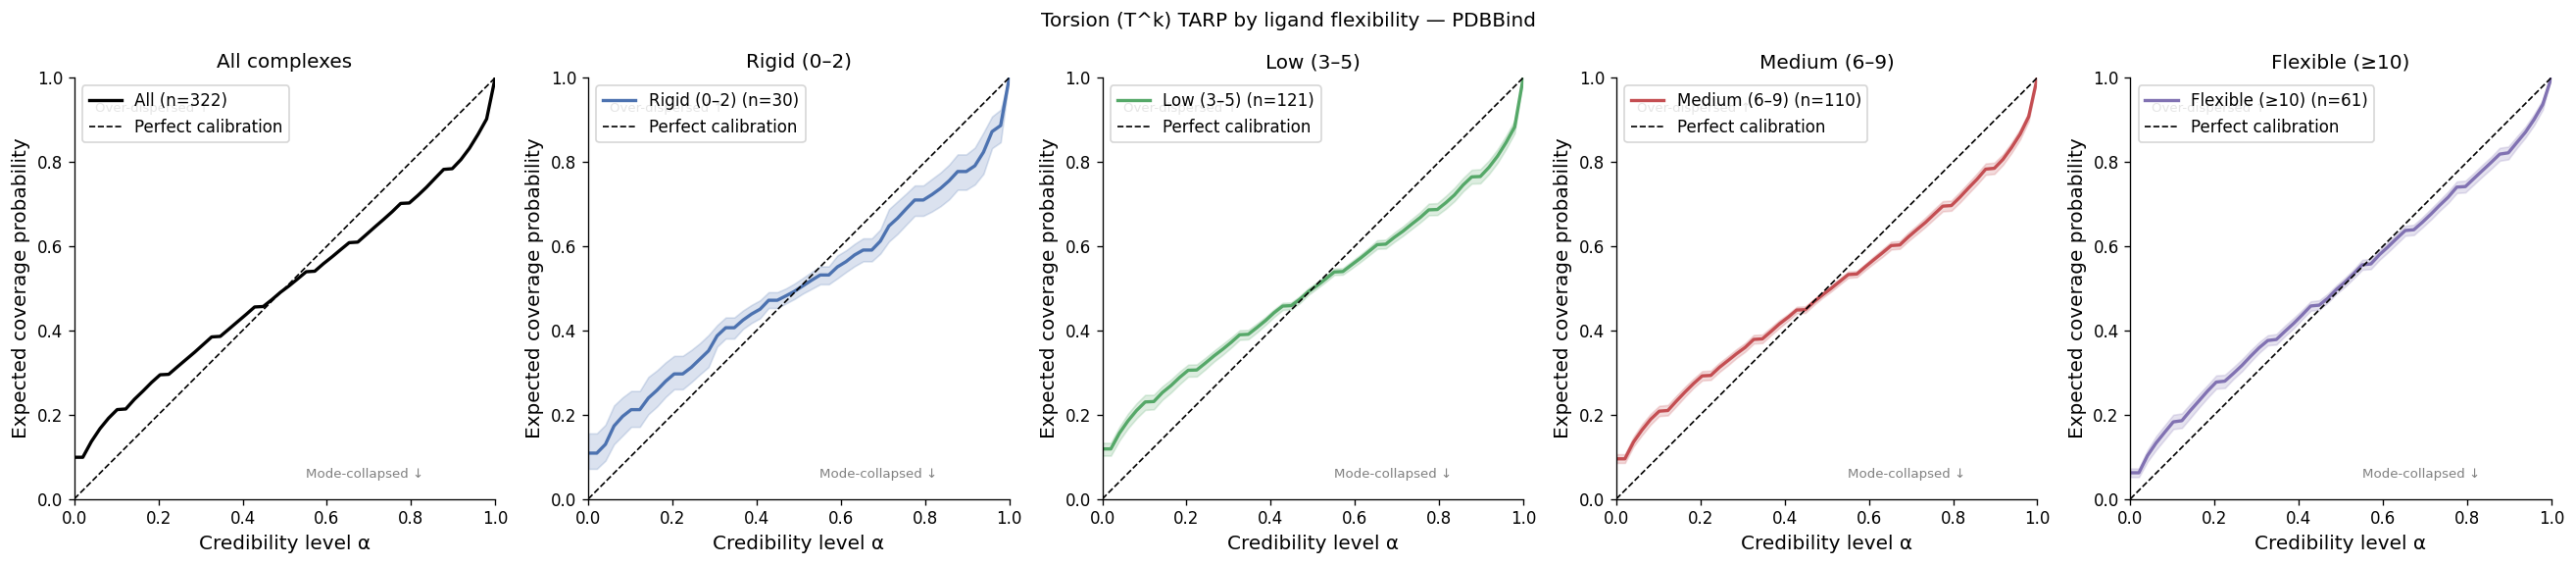

In [11]:
FLEX_BINS   = [0, 3, 6, 10, 999]
FLEX_LABELS = ['Rigid (0–2)', 'Low (3–5)', 'Medium (6–9)', 'Flexible (≥10)']
FLEX_COLORS = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

def flex_bin(n):
    for i in range(len(FLEX_BINS) - 1):
        if FLEX_BINS[i] <= n < FLEX_BINS[i + 1]:
            return i
    return len(FLEX_LABELS) - 1

# ── TARP ECP by flexibility ───────────────────────────────────────────────────
if pdb_names_tarp is not None and pdb_nrot_tarp is not None and all(pdb_tarp[g] is not None for g in GROUPS):
    bins = np.array([flex_bin(n) for n in pdb_nrot_tarp])

    for g in GROUPS:
        # 1 overall panel + 4 flex-bin panels = 5 axes total
        fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
        f_all = pdb_tarp[g]
        ecp, alpha = ecp_from_fractions(f_all)
        plot_ecp(ecp, alpha, ax=axes[0], label=f'All (n={len(f_all)})', color='k')
        axes[0].set_title('All complexes')
        for i, (lbl, col) in enumerate(zip(FLEX_LABELS, FLEX_COLORS)):
            mask = bins == i
            ax = axes[i + 1]
            if mask.sum() < 5:
                ax.text(0.5, 0.5, f'n={mask.sum()}\n(too few)', ha='center', va='center')
                ax.set_title(lbl)
                continue
            f_sub = f_all[mask]
            ecp, alpha = ecp_from_fractions(f_sub)
            boot = bootstrap_ecp(f_sub, n_bootstrap=300)
            plot_ecp(ecp, alpha, ax=ax, label=f'{lbl} (n={mask.sum()})', color=col, bootstrap_ecps=boot)
            ax.set_title(lbl)
        fig.suptitle(f'{LABELS[g]} TARP by ligand flexibility — PDBBind', fontsize=12, y=1.01)
        plt.tight_layout()
        plt.savefig(f'{FIGURES}/group_tarp_{g}_by_flex_pdbbind.png', dpi=150, bbox_inches='tight')
        plt.show()
else:
    print('PDBBind group TARP + n_rot_bonds data not yet available.')

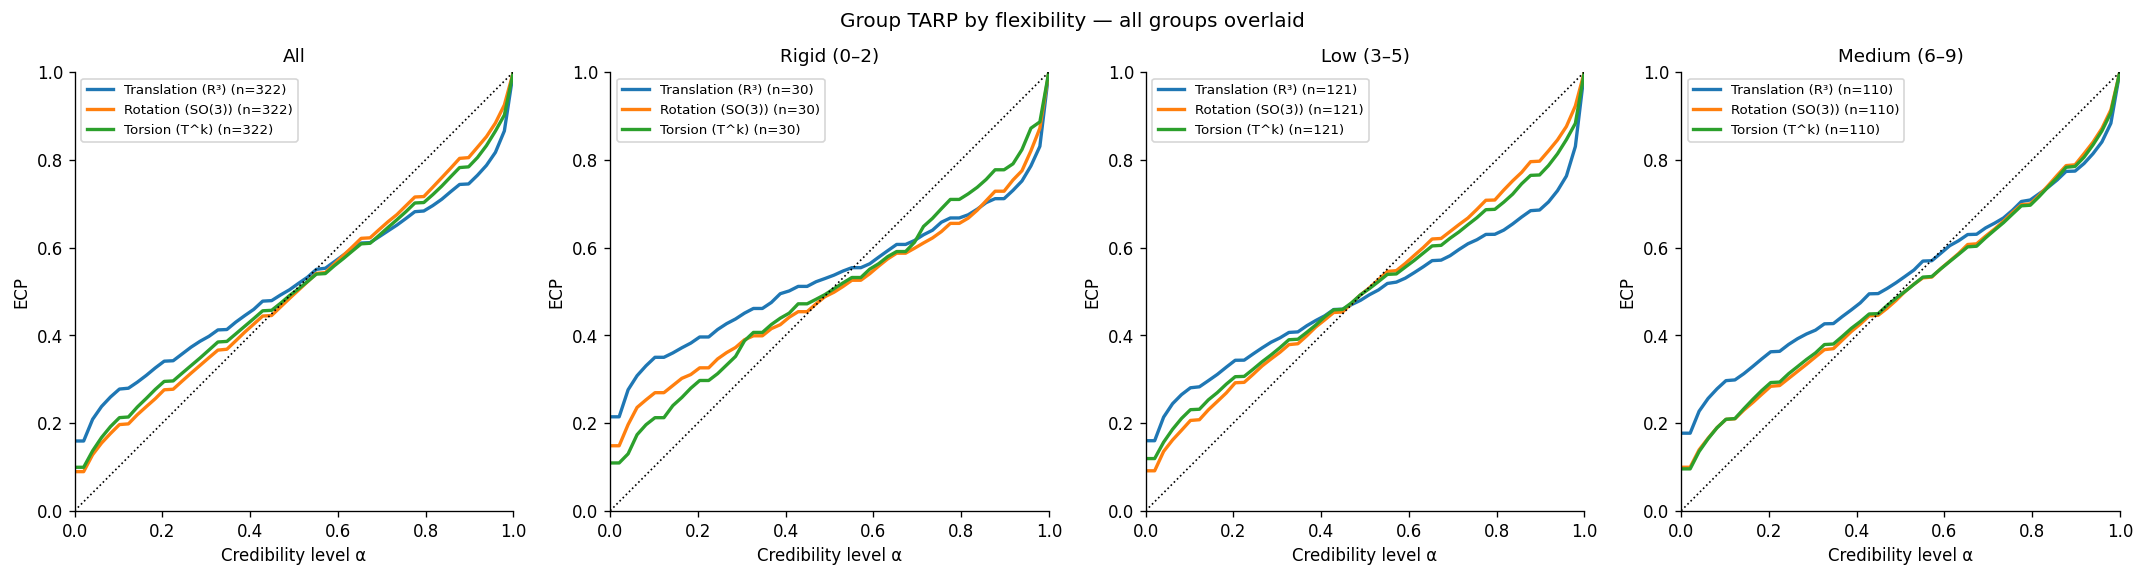

In [12]:
# 4b: Overlay all three groups for each flexibility bin
if pdb_names_tarp is not None and pdb_nrot_tarp is not None and all(pdb_tarp[g] is not None for g in GROUPS):
    bins = np.array([flex_bin(n) for n in pdb_nrot_tarp])
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
    for i, (lbl, ax) in enumerate(zip(['All'] + FLEX_LABELS, axes)):
        mask = np.ones(len(pdb_nrot_tarp), dtype=bool) if i == 0 else (bins == i - 1)
        for g in GROUPS:
            f_sub = pdb_tarp[g][mask]
            if f_sub.shape[0] < 5:
                continue
            ecp, alpha = ecp_from_fractions(f_sub)
            ax.plot(alpha, ecp, color=COLORS[g], lw=2, label=f'{LABELS[g]} (n={mask.sum()})')
        ax.plot([0, 1], [0, 1], 'k:', lw=1)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
        ax.set_xlabel('Credibility level α'); ax.set_ylabel('ECP')
        ax.set_title(lbl, fontsize=11)
        ax.legend(fontsize=8)
    fig.suptitle('Group TARP by flexibility — all groups overlaid', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/group_tarp_by_flex_overlay_pdbbind.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Data not yet available.')

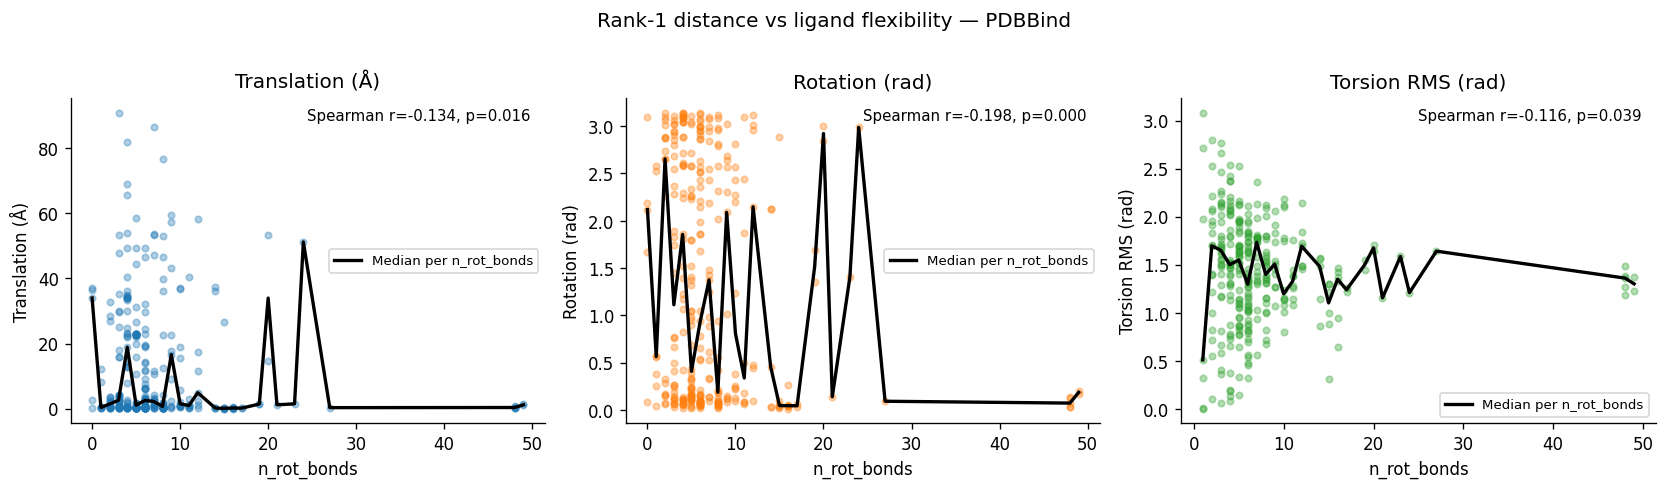

In [13]:
# 4c: Rank-1 distance vs n_rot_bonds scatter (one panel per group)
if pdb_names_dist is not None and pdb_nrot is not None and all(pdb_dist[k] is not None for k in dist_keys):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, key in zip(axes, dist_keys):
        rank1 = pdb_dist[key][:, 0]
        valid = np.isfinite(rank1) & np.isfinite(pdb_nrot.astype(float))
        x = pdb_nrot[valid]
        y = rank1[valid]
        col = COLORS['torsion'] if key == 'torsion_rms' else COLORS[key]
        ax.scatter(x, y, color=col, alpha=0.35, s=15)
        xuniq = np.unique(x)
        med_y = [np.median(y[x == xv]) for xv in xuniq]
        ax.plot(xuniq, med_y, 'k-', lw=2, label='Median per n_rot_bonds')
        r, p = stats.spearmanr(x, y)
        ax.set_xlabel('n_rot_bonds')
        ax.set_ylabel(dist_labels[key])
        ax.set_title(dist_labels[key])
        ax.text(0.97, 0.97, f'Spearman r={r:.3f}, p={p:.3f}',
                transform=ax.transAxes, ha='right', va='top', fontsize=9)
        ax.legend(fontsize=8)
    fig.suptitle('Rank-1 distance vs ligand flexibility — PDBBind', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/group_rank1_dist_vs_flex_pdbbind.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Data not yet available.')

## 5 · Stratification by Protein Family

Uses the pre-built `pdb_annotations.csv` protein class annotations.
Same 7-group taxonomy as the existing TARP/MIRA notebook.

In [14]:
import pandas as pd

ANN_PATH = '/home/qf226/rds/hpc-work/data/inference/pdb_annotations.csv'
if os.path.exists(ANN_PATH):
    ann = pd.read_csv(ANN_PATH)
    ann_map = dict(zip(ann['pdb_id'], ann['protein_class'].fillna('Unknown')))
else:
    print('pdb_annotations.csv not found — protein family analysis unavailable.')
    ann_map = {}

FAM_GROUPS = [
    ('Hydrolases',         lambda c: 'hydrolase'     in c.lower()),
    ('Transferases',       lambda c: 'transferase'   in c.lower()),
    ('Sugar Binding',      lambda c: 'sugar binding' in c.lower()),
    ('Signaling',          lambda c: 'signaling'     in c.lower()),
    ('Transcription/Gene', lambda c: any(k in c.lower() for k in
                                         ('transcription', 'nuclear protein',
                                          'dna binding', 'rna binding', 'gene regulation'))),
    ('Oxidoreductases',    lambda c: 'oxidoreductase' in c.lower()),
    ('Other',              lambda c: True),
]
FAM_NAMES  = [f[0] for f in FAM_GROUPS]
FAM_COLORS = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6']

def assign_family(pdb_id):
    pc = ann_map.get(pdb_id, 'Unknown')
    for name, fn in FAM_GROUPS:
        if fn(pc):
            return name
    return 'Other'

print('Family taxonomy loaded.')

Family taxonomy loaded.


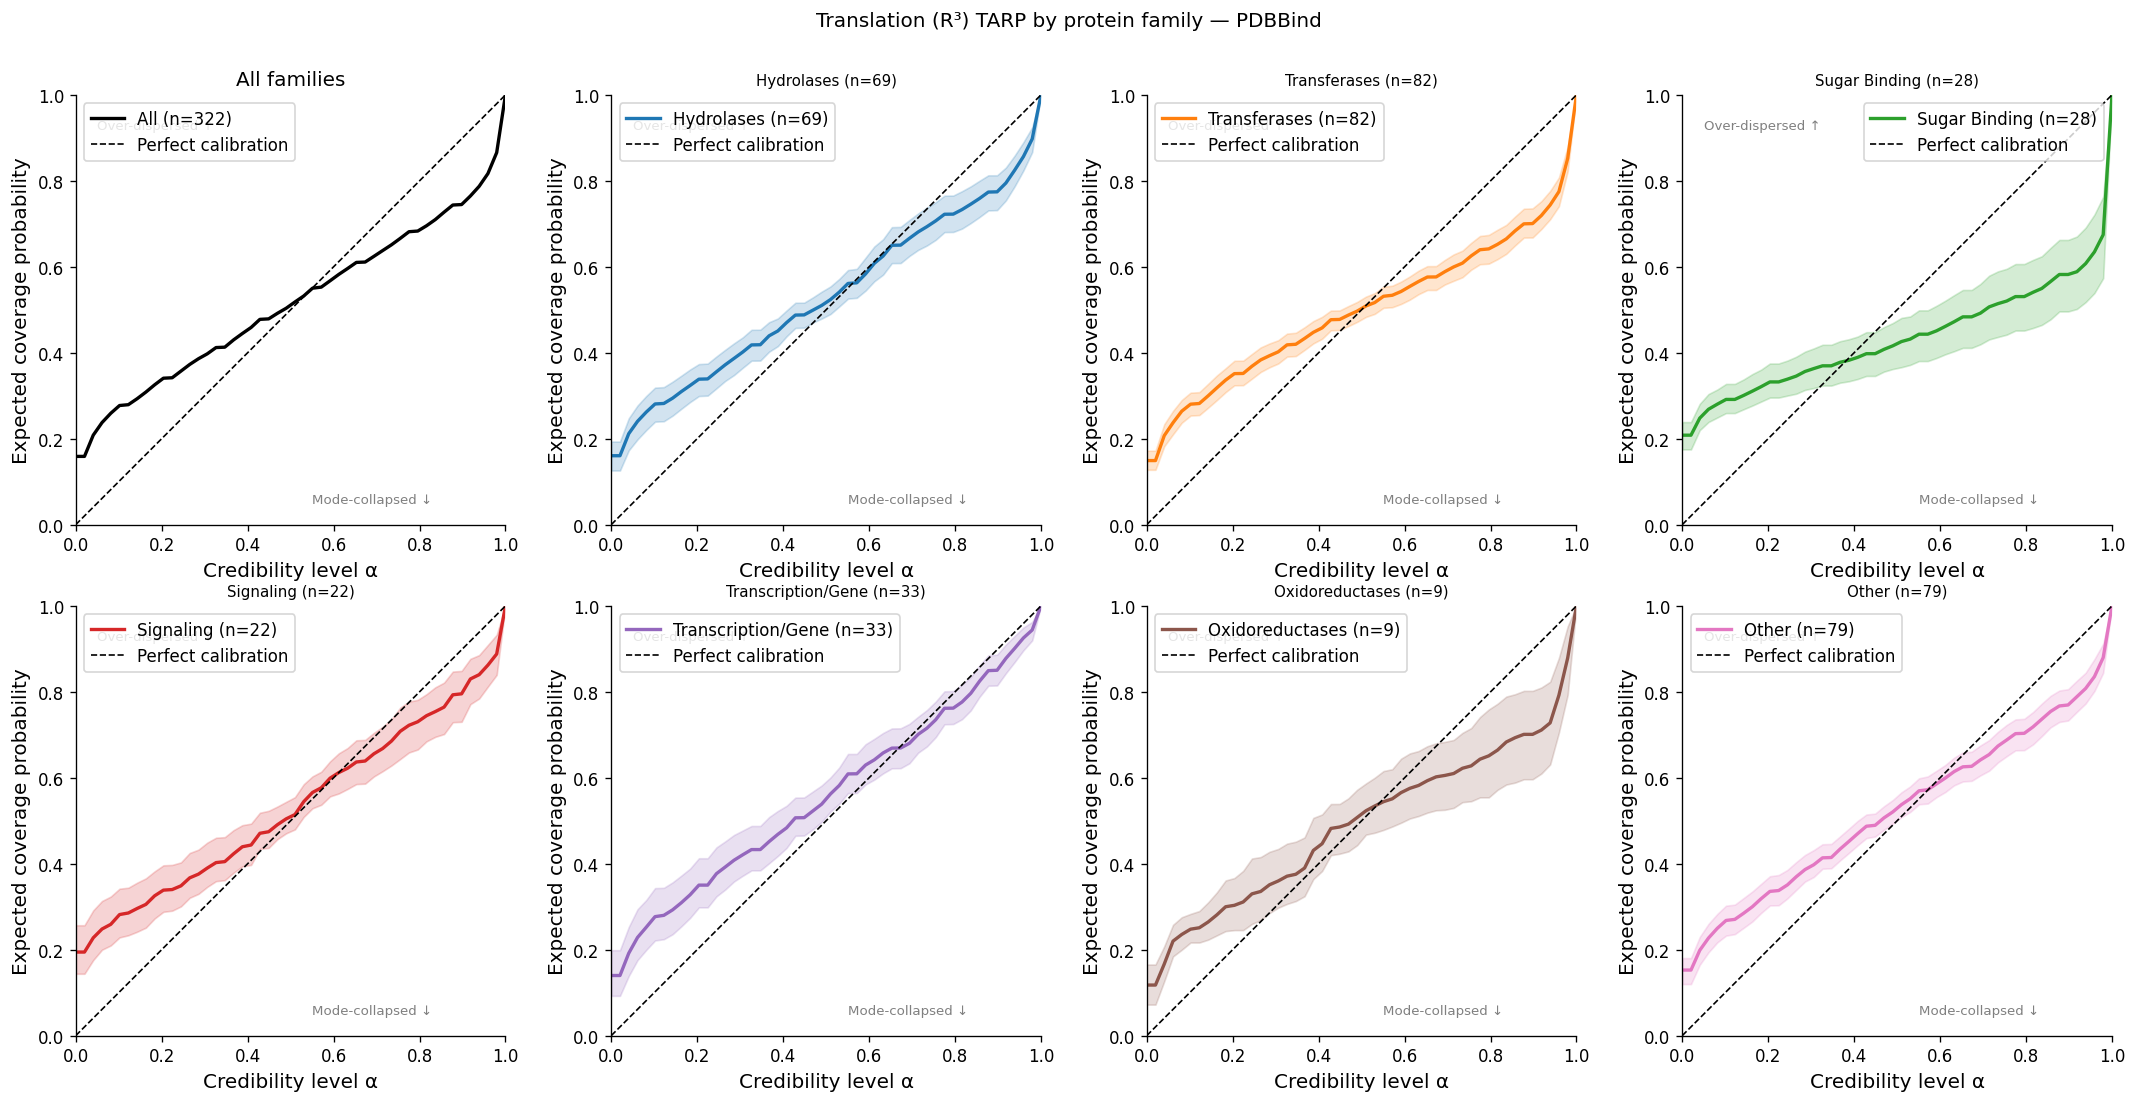

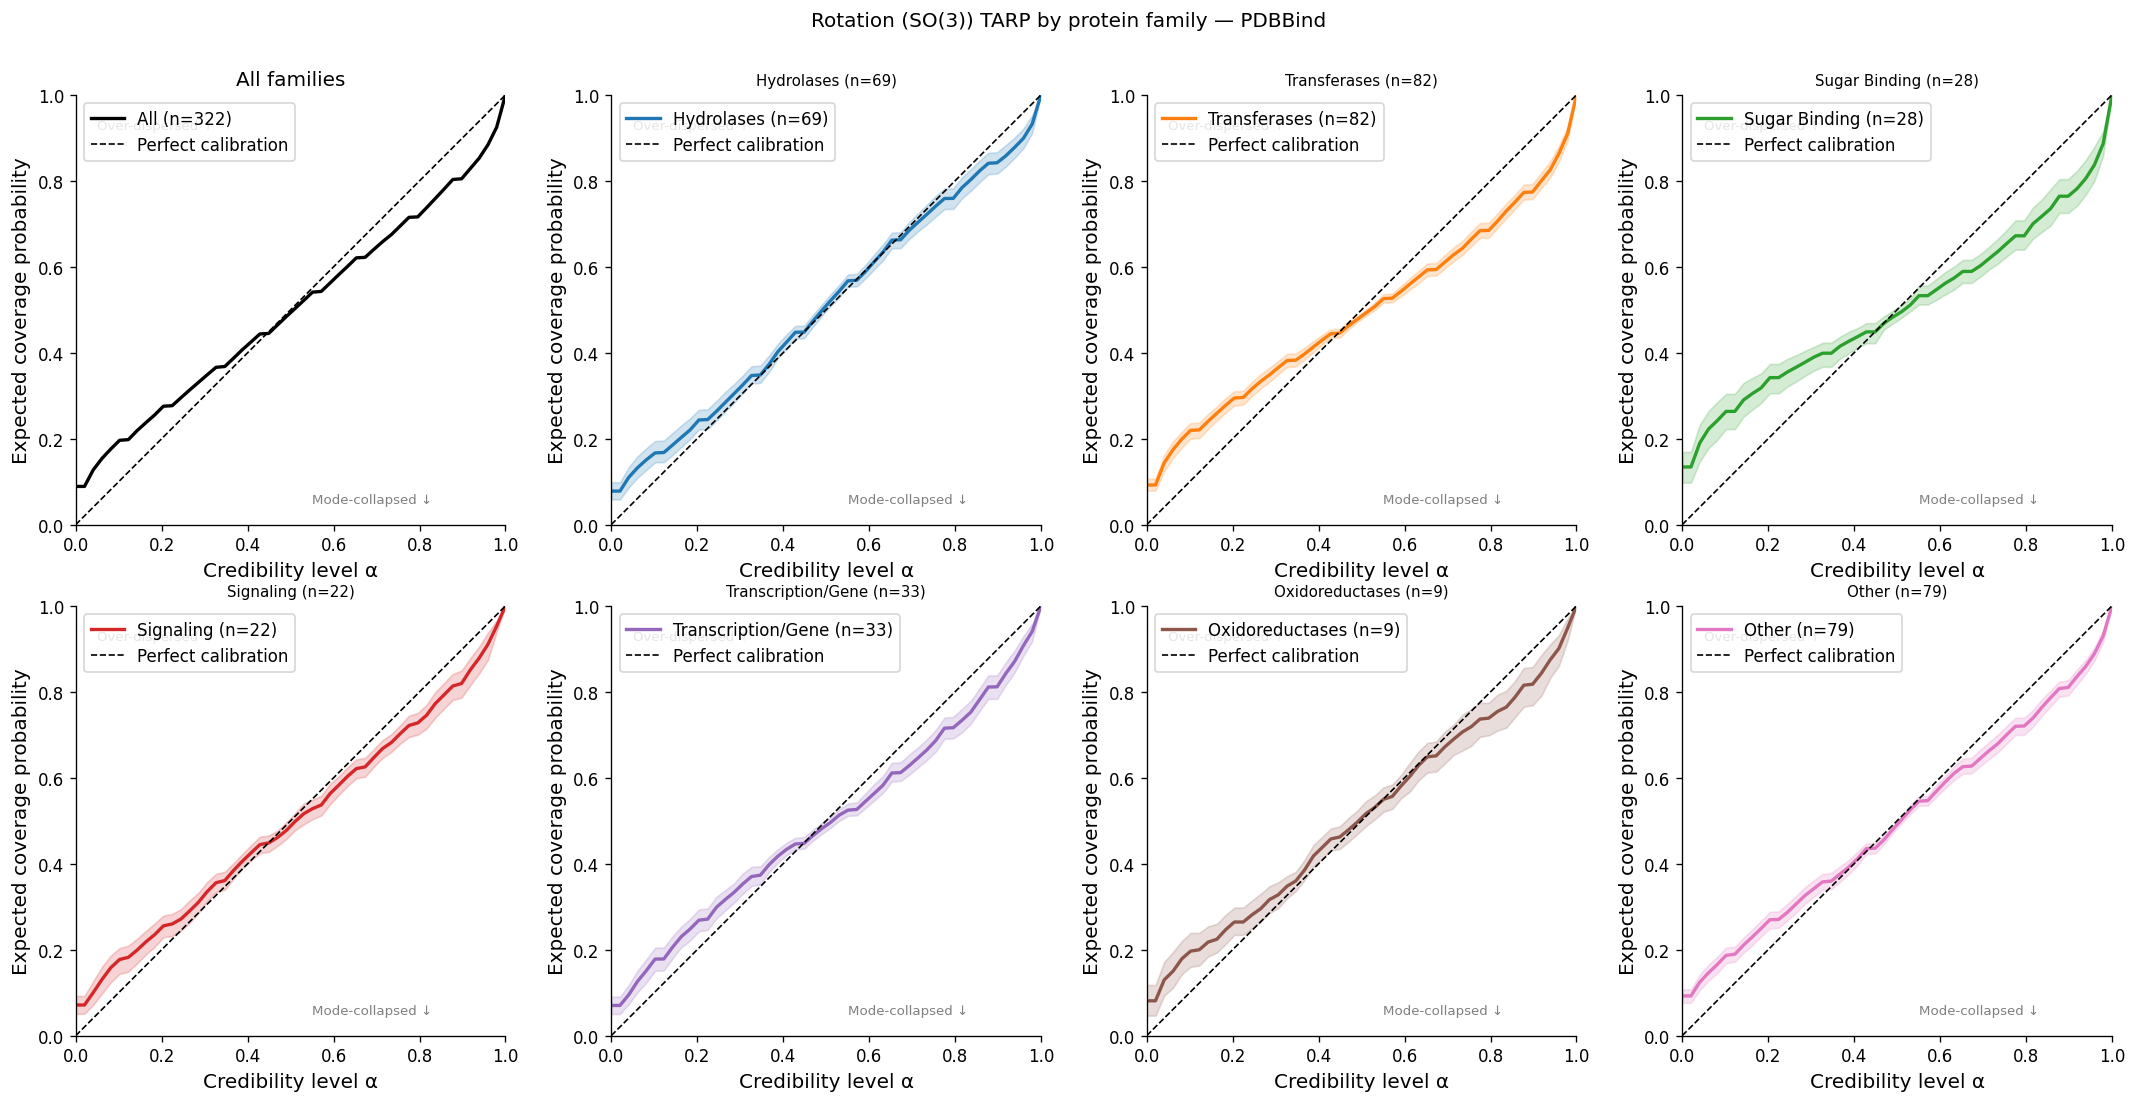

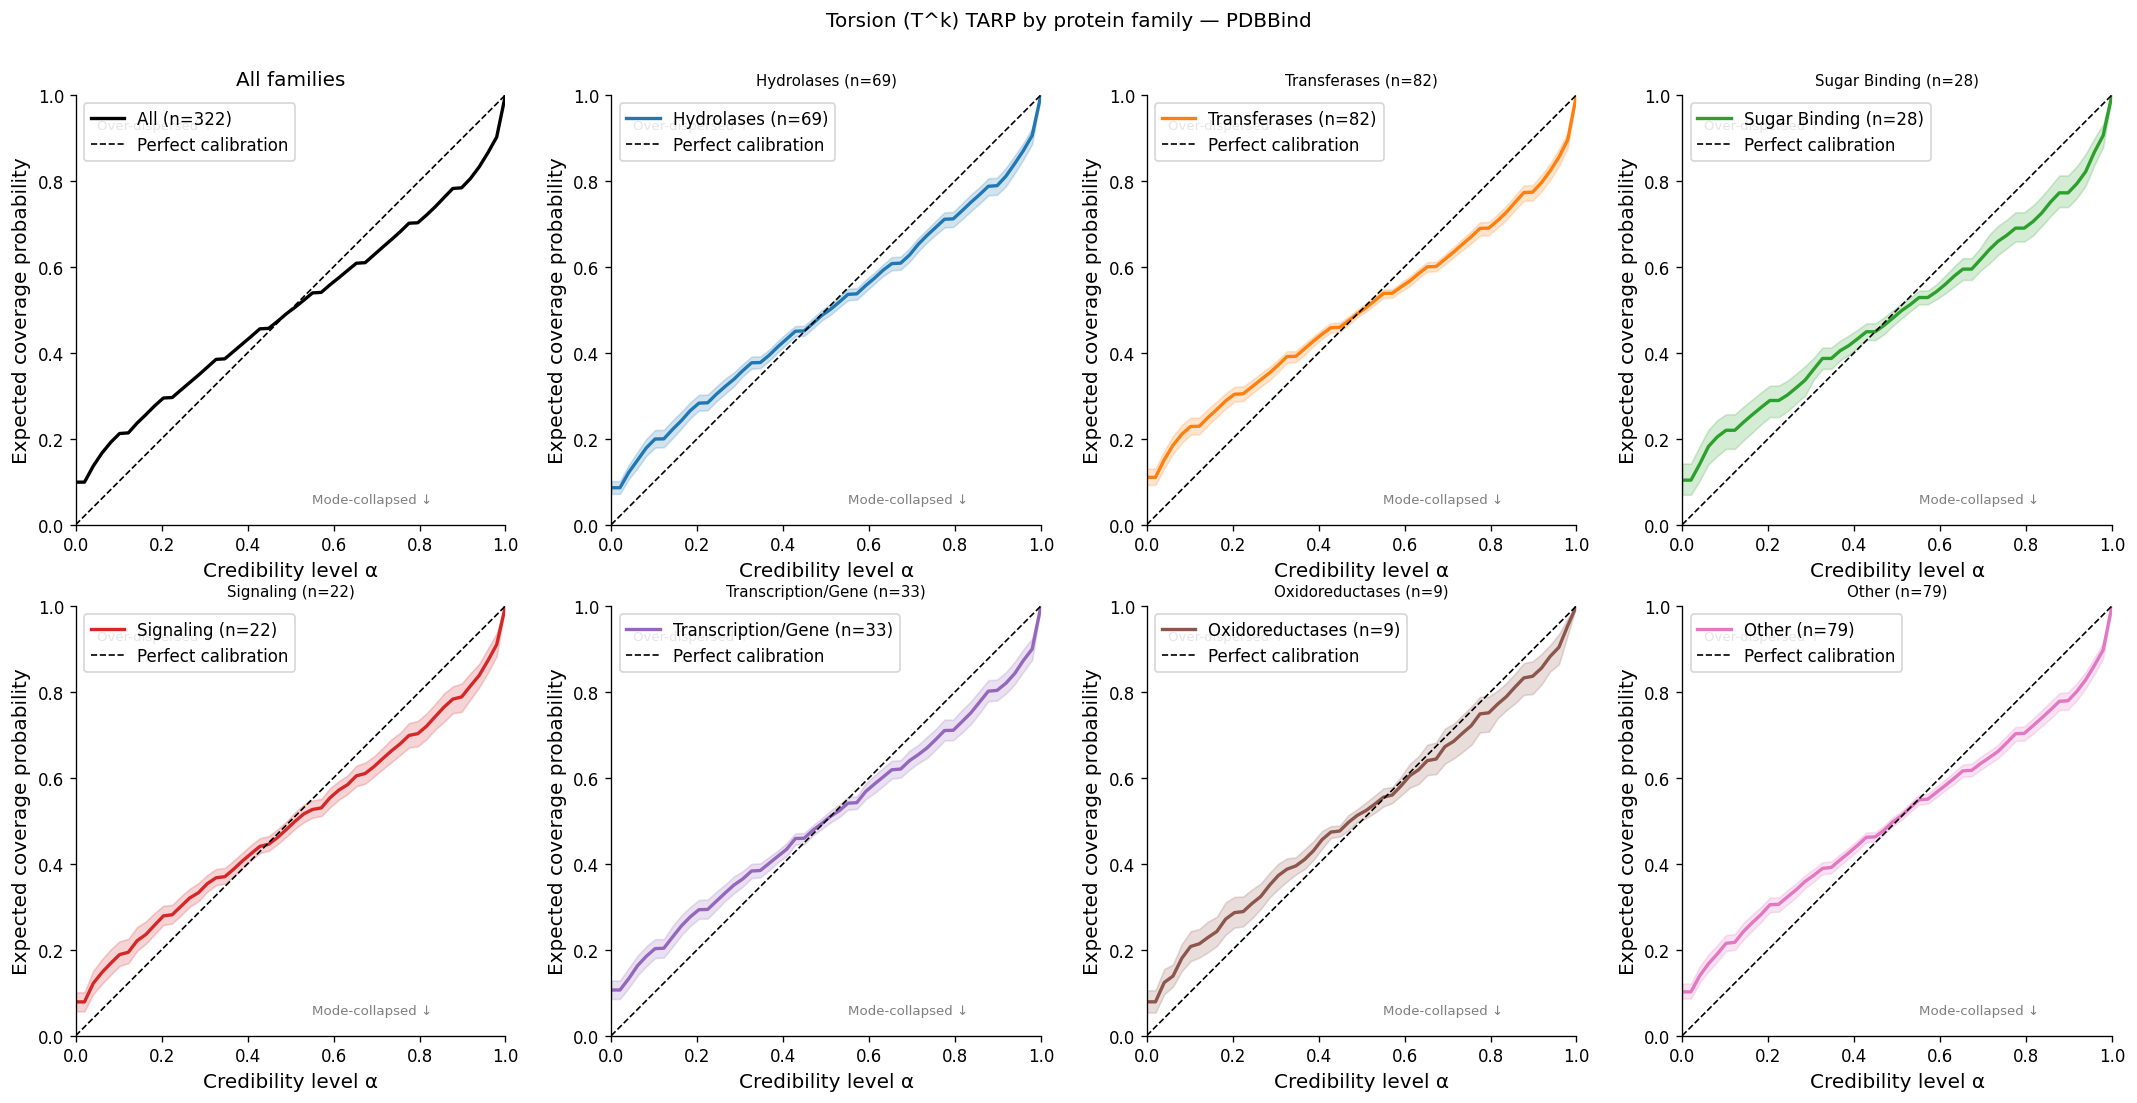

In [15]:
# 5a: ECP curves per family, one figure per group (3 × 7 panels)
if pdb_names_tarp is not None and ann_map and all(pdb_tarp[g] is not None for g in GROUPS):
    fam_labels = np.array([assign_family(n) for n in pdb_names_tarp])

    for g in GROUPS:
        f_all = pdb_tarp[g]
        ncols = 4
        nrows = (len(FAM_NAMES) + 1 + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 4.5))
        axes = axes.ravel()

        ecp_all, alpha_all = ecp_from_fractions(f_all)
        plot_ecp(ecp_all, alpha_all, ax=axes[0], label=f'All (n={len(f_all)})', color='k')
        axes[0].set_title('All families')

        for i, (fname, fcolor) in enumerate(zip(FAM_NAMES, FAM_COLORS)):
            mask = fam_labels == fname
            ax = axes[i + 1]
            if mask.sum() < 5:
                ax.text(0.5, 0.5, f'n={mask.sum()}\n(too few)', ha='center', va='center')
                ax.set_title(fname, fontsize=9)
                continue
            f_sub = f_all[mask]
            ecp, alpha = ecp_from_fractions(f_sub)
            boot = bootstrap_ecp(f_sub, n_bootstrap=300)
            plot_ecp(ecp, alpha, ax=ax, label=f'{fname} (n={mask.sum()})', color=fcolor, bootstrap_ecps=boot)
            ax.set_title(f'{fname} (n={mask.sum()})', fontsize=9)

        for j in range(len(FAM_NAMES) + 1, len(axes)):
            axes[j].set_visible(False)

        fig.suptitle(f'{LABELS[g]} TARP by protein family — PDBBind', fontsize=12, y=1.01)
        plt.tight_layout()
        plt.savefig(f'{FIGURES}/group_tarp_{g}_by_family_pdbbind.png', dpi=150, bbox_inches='tight')
        plt.show()
else:
    print('Data or annotations not yet available.')

In [16]:
# 5b: MIRA score per protein family — one row per family, one column per group
if pdb_group_mira and ann_map:
    print(f'{"Family":<22} {"N":>4}  ' + '  '.join(f'{LABELS[g]:>36}' for g in GROUPS))
    print('-' * (22 + 4 + 3 * 38))
    for fname in FAM_NAMES:
        row = f'{fname:<22}'
        for g in GROUPS:
            names_g  = pdb_group_mira.get(g, {}).get('names',  np.array([]))
            scores_g = pdb_group_mira.get(g, {}).get('scores', np.array([]))
            fam_lbl  = np.array([assign_family(n) for n in names_g])
            mask     = fam_lbl == fname
            n        = mask.sum()
            if n == 0:
                row += f'  {"-":>36}'
            else:
                m   = scores_g[mask].mean()
                dev = m - MIRA_NULL_40
                tag = 'over-disp' if dev > 0.03 else ('mode-coll' if dev < -0.03 else 'calibrated')
                row += f'  {m:>7.4f} +/- {scores_g[mask].std():>6.4f}  (n={n:3d}) {tag}'
        print(row)
    print(f'\n(null = {MIRA_NULL_40:.4f};  > null => over-dispersed,  < null => mode-collapsed)')
else:
    print('MIRA scores or annotations not yet available -- run cell 2.5a first.')

Family                    N                      Translation (R³)                      Rotation (SO(3))                         Torsion (T^k)
--------------------------------------------------------------------------------------------------------------------------------------------
Hydrolases               0.6258 +/- 0.0653  (n= 69) mode-coll   0.6503 +/- 0.0606  (n= 69) mode-coll   0.6445 +/- 0.0455  (n= 69) mode-coll
Transferases             0.6016 +/- 0.0570  (n= 82) mode-coll   0.6354 +/- 0.0472  (n= 82) mode-coll   0.6324 +/- 0.0460  (n= 81) mode-coll
Sugar Binding            0.5804 +/- 0.0584  (n= 28) mode-coll   0.6217 +/- 0.0536  (n= 28) mode-coll   0.6413 +/- 0.0507  (n= 28) mode-coll
Signaling                0.6149 +/- 0.0621  (n= 22) mode-coll   0.6611 +/- 0.0323  (n= 22) calibrated   0.6399 +/- 0.0452  (n= 22) mode-coll
Transcription/Gene       0.6410 +/- 0.0474  (n= 33) mode-coll   0.6515 +/- 0.0377  (n= 33) mode-coll   0.6492 +/- 0.0433  (n= 32) mode-coll
Oxidoreductases 

## 6 · Correlation Across Groups

Are the calibration errors correlated? A complex that is overconfident in translation —
does it also tend to be overconfident in rotation/torsion?

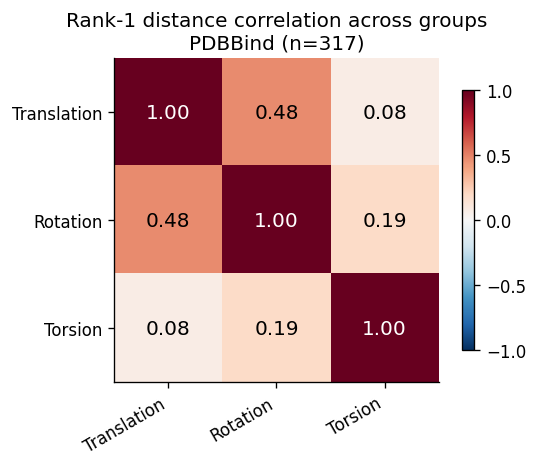

Translation vs Rotation: Spearman r=0.723, p=0.0000
Translation vs Torsion: Spearman r=0.166, p=0.0030
Rotation vs Torsion: Spearman r=0.238, p=0.0000


In [17]:
# 6a: Rank-1 distance correlation matrix
if pdb_names_dist is not None and all(pdb_dist[k] is not None for k in dist_keys):
    # Use rank-1 pose distances
    d_tr = pdb_dist['translation'][:, 0]
    d_ro = pdb_dist['rotation'][:, 0]
    d_to = pdb_dist['torsion_rms'][:, 0]

    valid = np.isfinite(d_tr) & np.isfinite(d_ro) & np.isfinite(d_to)
    D = np.column_stack([d_tr[valid], d_ro[valid], d_to[valid]])
    corr = np.corrcoef(D.T)

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(['Translation', 'Rotation', 'Torsion'], rotation=30, ha='right')
    ax.set_yticklabels(['Translation', 'Rotation', 'Torsion'])
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{corr[i, j]:.2f}', ha='center', va='center',
                    color='w' if abs(corr[i, j]) > 0.6 else 'k', fontsize=12)
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title('Rank-1 distance correlation across groups\nPDBBind (n={})'.format(valid.sum()))
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/group_dist_corr_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    for i, gi in enumerate(['Translation', 'Rotation', 'Torsion']):
        for j, gj in enumerate(['Translation', 'Rotation', 'Torsion']):
            if j > i:
                r, p = stats.spearmanr(D[:, i], D[:, j])
                print(f'{gi} vs {gj}: Spearman r={r:.3f}, p={p:.4f}')
else:
    print('Distance data not yet available.')

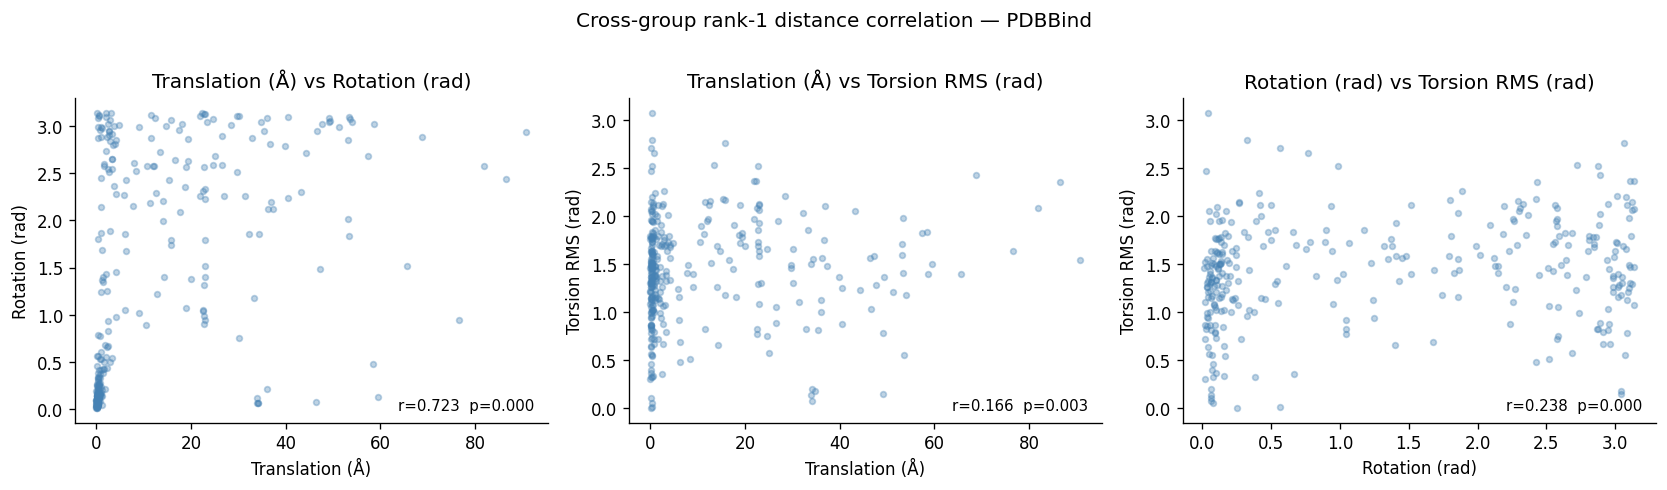

In [18]:
# 6b: Cross-group rank-1 distance scatter
if pdb_names_dist is not None and all(pdb_dist[k] is not None for k in dist_keys):
    d_tr = pdb_dist['translation'][:, 0]
    d_ro = pdb_dist['rotation'][:, 0]
    d_to = pdb_dist['torsion_rms'][:, 0]
    valid = np.isfinite(d_tr) & np.isfinite(d_ro) & np.isfinite(d_to)

    pairs = [('translation', 'rotation'), ('translation', 'torsion_rms'), ('rotation', 'torsion_rms')]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, (k1, k2) in zip(axes, pairs):
        x = pdb_dist[k1][:, 0][valid]
        y = pdb_dist[k2][:, 0][valid]
        ax.scatter(x, y, color='steelblue', alpha=0.35, s=12)
        r, p = stats.spearmanr(x, y)
        ax.set_xlabel(dist_labels[k1])
        ax.set_ylabel(dist_labels[k2])
        ax.set_title(f'{dist_labels[k1]} vs {dist_labels[k2]}')
        ax.text(0.97, 0.03, f'r={r:.3f}  p={p:.3f}',
                transform=ax.transAxes, ha='right', va='bottom', fontsize=9)
    fig.suptitle('Cross-group rank-1 distance correlation — PDBBind', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/group_rank1_dist_cross_group.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Data not yet available.')

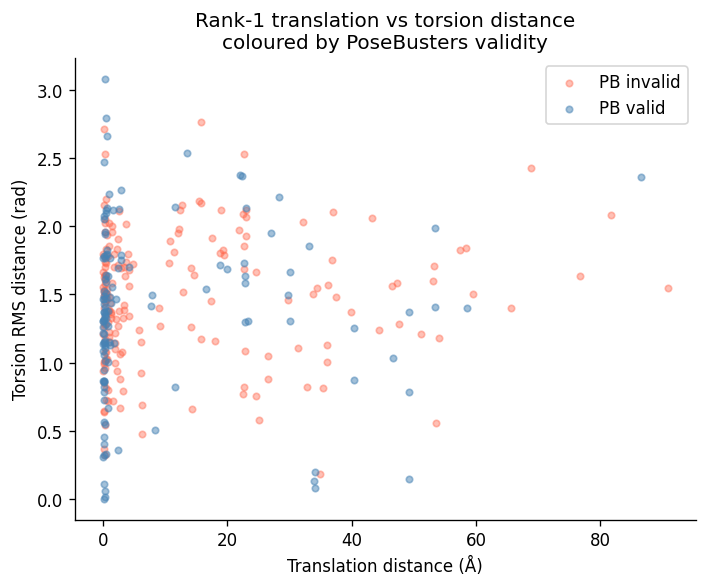

PB valid rank-1: 40.4% of 317 complexes with distances


In [19]:
# 6c: Translation vs torsion distance coloured by PoseBusters validity
if (pdb_names_dist is not None and all(pdb_dist[k] is not None for k in dist_keys)
        and pb_validity):
    # PoseBusters validity for rank-1 on PDBBind set
    rank1_valid = np.array([
        'rank1.sdf' in pb_validity.get(n, {}).get('valid_ranks', []) or
        'rank1_confidence-1.sdf' in str(pb_validity.get(n, {}).get('valid_ranks', []))
        for n in pdb_names_dist
    ])

    d_tr = pdb_dist['translation'][:, 0]
    d_to = pdb_dist['torsion_rms'][:, 0]
    valid = np.isfinite(d_tr) & np.isfinite(d_to)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(d_tr[valid & ~rank1_valid], d_to[valid & ~rank1_valid],
               color='tomato', alpha=0.4, s=15, label='PB invalid')
    ax.scatter(d_tr[valid & rank1_valid],  d_to[valid & rank1_valid],
               color='steelblue', alpha=0.5, s=15, label='PB valid')
    ax.set_xlabel('Translation distance (Å)')
    ax.set_ylabel('Torsion RMS distance (rad)')
    ax.set_title('Rank-1 translation vs torsion distance\ncoloured by PoseBusters validity')
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/group_dist_tr_vs_tors_pb_validity.png', dpi=150, bbox_inches='tight')
    plt.show()
    pct_valid = rank1_valid[valid].mean() * 100
    print(f'PB valid rank-1: {pct_valid:.1f}% of {valid.sum()} complexes with distances')
else:
    print('Data not yet available.')

## 7 · Connection to PoseBusters Failures

Does calibration depend on whether the pose passes physical validity checks?
Split complexes into PoseBusters-valid (rank-1 passes all checks) vs invalid.

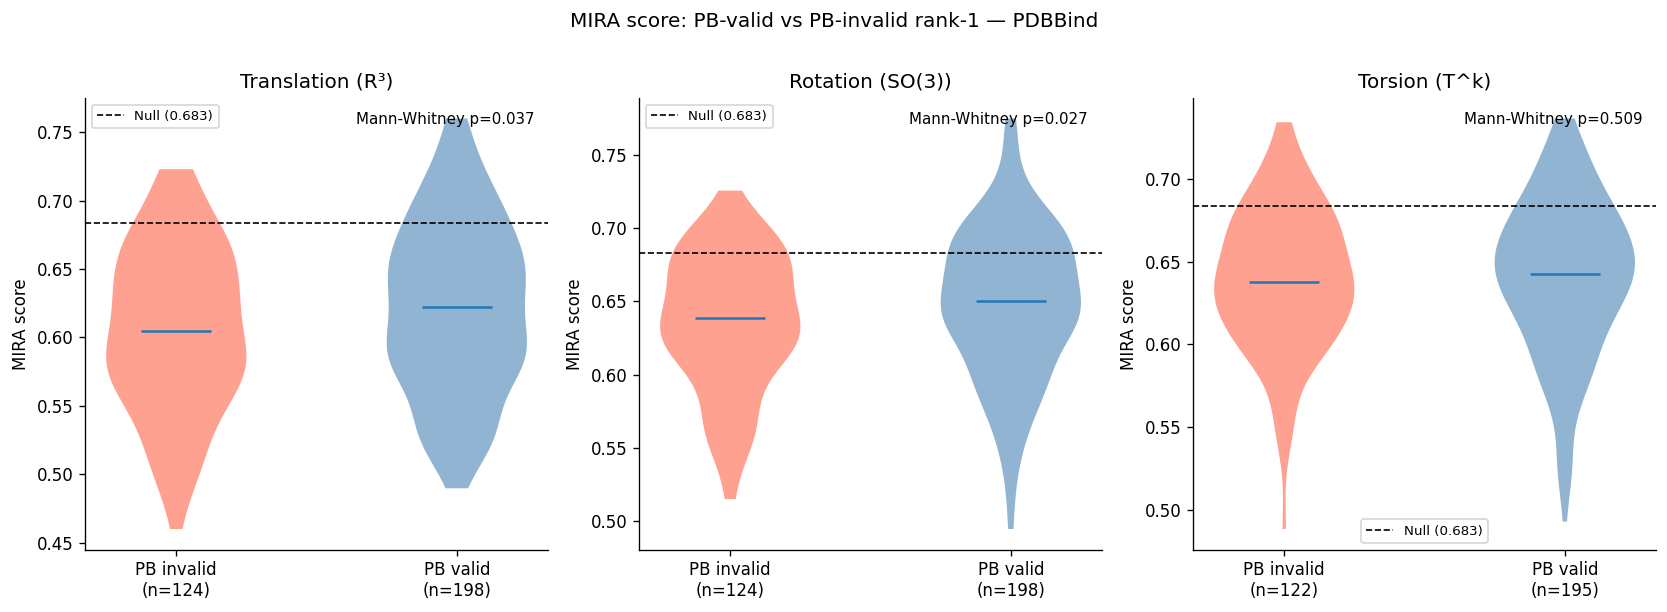

In [20]:
# 7a: MIRA score violin plots \u2014 PB valid vs PB invalid rank-1 (per group)
if pdb_group_mira and pb_validity:
    def _is_rank1_valid(pdb_id):
        vr = pb_validity.get(pdb_id, {}).get('valid_ranks', [])
        return any('rank1' in r for r in vr)

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    for ax, g in zip(axes, GROUPS):
        names_g  = pdb_group_mira.get(g, {}).get('names',  np.array([]))
        scores_g = pdb_group_mira.get(g, {}).get('scores', np.array([]))
        if len(scores_g) == 0:
            ax.text(0.5, 0.5, 'No MIRA data', ha='center', va='center',
                    transform=ax.transAxes)
            ax.set_title(LABELS[g])
            continue
        pb_mask   = np.array([_is_rank1_valid(n) for n in names_g])
        valid_s   = scores_g[ pb_mask & np.isfinite(scores_g)]
        invalid_s = scores_g[~pb_mask & np.isfinite(scores_g)]
        vp = ax.violinplot([invalid_s, valid_s], positions=[0, 1],
                           showmedians=True, showextrema=False)
        vp['bodies'][0].set_facecolor('tomato');    vp['bodies'][0].set_alpha(0.6)
        vp['bodies'][1].set_facecolor('steelblue'); vp['bodies'][1].set_alpha(0.6)
        ax.axhline(MIRA_NULL_40, color='k', ls='--', lw=1,
                   label=f'Null ({MIRA_NULL_40:.3f})')
        ax.set_xticks([0, 1])
        ax.set_xticklabels([f'PB invalid\n(n={len(invalid_s)})',
                             f'PB valid\n(n={len(valid_s)})'])
        ax.set_ylabel('MIRA score')
        ax.set_title(LABELS[g])
        u, p = stats.mannwhitneyu(invalid_s, valid_s, alternative='two-sided')
        ax.text(0.97, 0.97, f'Mann-Whitney p={p:.3f}',
                transform=ax.transAxes, ha='right', va='top', fontsize=9)
        ax.legend(fontsize=8)
    fig.suptitle('MIRA score: PB-valid vs PB-invalid rank-1 \u2014 PDBBind', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/group_mira_pb_valid_vs_invalid.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('MIRA scores or PoseBusters validity data not yet available \u2014 run cell 2.5a first.')

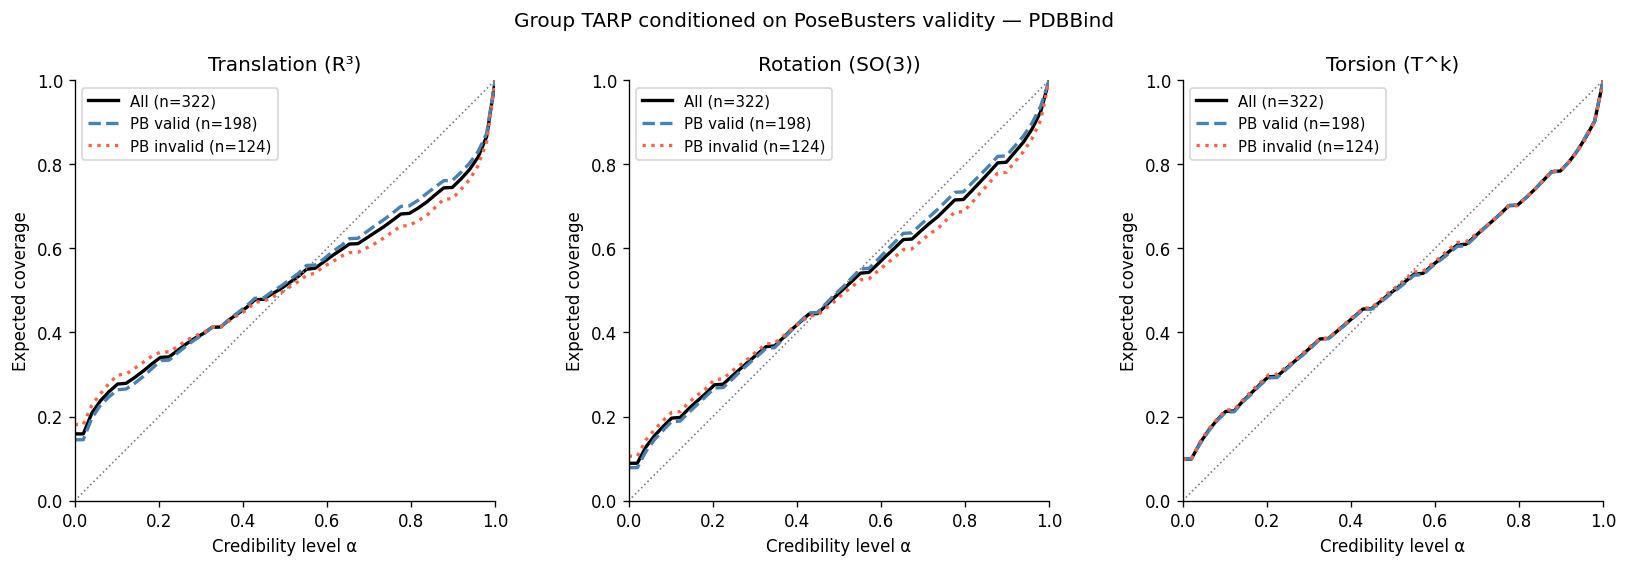

In [21]:
# 7b: ECP curves conditioned on PB validity
if pdb_names_tarp is not None and pb_validity and all(pdb_tarp[g] is not None for g in GROUPS):
    def _is_rank1_valid(pdb_id):
        vr = pb_validity.get(pdb_id, {}).get('valid_ranks', [])
        return any('rank1' in r for r in vr)

    pb_mask = np.array([_is_rank1_valid(n) for n in pdb_names_tarp])

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    for ax, g in zip(axes, GROUPS):
        f = pdb_tarp[g]
        for mask, lbl, col, ls in [
            (np.ones(len(pb_mask), dtype=bool), 'All', 'k',         '-'),
            (pb_mask,                           'PB valid',   'steelblue', '--'),
            (~pb_mask,                          'PB invalid', 'tomato',    ':'),
        ]:
            f_sub = f[mask]
            if f_sub.shape[0] < 5:
                continue
            ecp, alpha = ecp_from_fractions(f_sub)
            ax.plot(alpha, ecp, color=col, ls=ls, lw=2, label=f'{lbl} (n={mask.sum()})')
        ax.plot([0, 1], [0, 1], 'grey', lw=1, ls='dotted')
        ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
        ax.set_xlabel('Credibility level α')
        ax.set_ylabel('Expected coverage')
        ax.set_title(LABELS[g])
        ax.legend(fontsize=9)
    fig.suptitle('Group TARP conditioned on PoseBusters validity — PDBBind', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/group_tarp_ecp_by_pb_validity.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Data not yet available.')

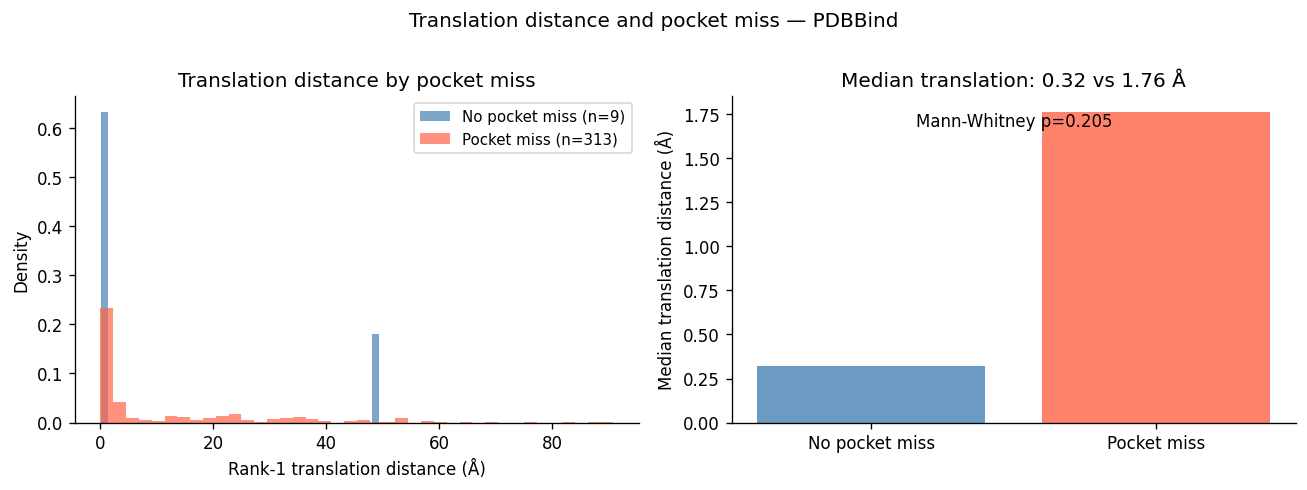

In [22]:
# 7c: Translation distance vs pocket miss (PB minimum_distance_to_protein check)
if pdb_names_dist is not None and pdb_dist['translation'] is not None and pb_validity:
    def _pocket_miss(pdb_id):
        """Returns True if rank-1 failed minimum_distance_to_protein."""
        cfs = pb_validity.get(pdb_id, {}).get('check_failures', {})
        return cfs.get('minimum_distance_to_protein', 0) > 0

    pocket_miss = np.array([_pocket_miss(n) for n in pdb_names_dist])
    d_tr = pdb_dist['translation'][:, 0]
    valid = np.isfinite(d_tr)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    ax = axes[0]
    ax.hist(d_tr[valid & ~pocket_miss], bins=40, color='steelblue', alpha=0.7, density=True,
            label=f'No pocket miss (n={(valid & ~pocket_miss).sum()})')
    ax.hist(d_tr[valid & pocket_miss],  bins=40, color='tomato',    alpha=0.7, density=True,
            label=f'Pocket miss (n={(valid & pocket_miss).sum()})')
    ax.set_xlabel('Rank-1 translation distance (Å)')
    ax.set_ylabel('Density')
    ax.set_title('Translation distance by pocket miss')
    ax.legend(fontsize=9)

    ax = axes[1]
    n_pm   = pocket_miss[valid].sum()
    n_npm  = (~pocket_miss[valid]).sum()
    m_pm   = np.nanmedian(d_tr[valid & pocket_miss])
    m_npm  = np.nanmedian(d_tr[valid & ~pocket_miss])
    ax.bar(['No pocket miss', 'Pocket miss'], [m_npm, m_pm],
           color=['steelblue', 'tomato'], alpha=0.8)
    ax.set_ylabel('Median translation distance (Å)')
    ax.set_title(f'Median translation: {m_npm:.2f} vs {m_pm:.2f} Å')
    u, p = stats.mannwhitneyu(d_tr[valid & ~pocket_miss], d_tr[valid & pocket_miss],
                              alternative='two-sided')
    ax.text(0.5, 0.95, f'Mann-Whitney p={p:.3f}', transform=ax.transAxes,
            ha='center', va='top', fontsize=10)

    fig.suptitle('Translation distance and pocket miss — PDBBind', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/group_translation_vs_pocket_miss.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Data not yet available.')

## 8 · PoseBusters Benchmark — Group TARP

Repeat key analyses on the PoseBusters benchmark set (303 complexes with newer ligands).
Unlike PDBBind, PoseBusters uses a flat directory layout.

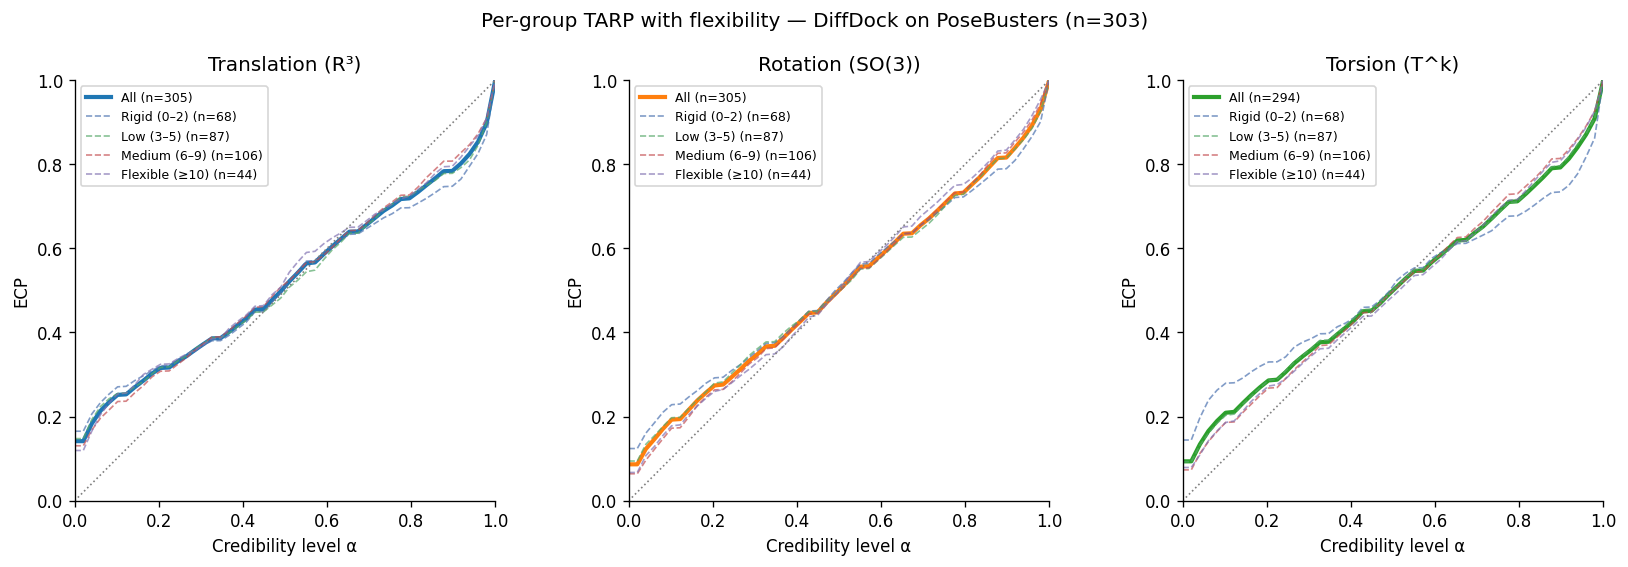

In [23]:
# 8a: Three-panel ECP — PoseBusters, with flexibility overlay
if (pb_names_tarp is not None and pb_nrot_tarp is not None
        and all(pb_tarp[g] is not None for g in GROUPS)):
    bins_pb = np.array([flex_bin(n) for n in pb_nrot_tarp])

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    for ax, g in zip(axes, GROUPS):
        f = pb_tarp[g]
        ecp, alpha = ecp_from_fractions(f)
        n_valid = np.sum(np.any(np.isfinite(f), axis=1))
        ax.plot(alpha, ecp, color=COLORS[g], lw=2.5, label=f'All (n={n_valid})')
        for bi, (bl, bc) in enumerate(zip(FLEX_LABELS, FLEX_COLORS)):
            mask = bins_pb == bi
            if mask.sum() < 5:
                continue
            ecp_sub, alpha_sub = ecp_from_fractions(f[mask])
            ax.plot(alpha_sub, ecp_sub, color=bc, lw=1, ls='--', alpha=0.7,
                    label=f'{bl} (n={mask.sum()})')
        ax.plot([0, 1], [0, 1], 'grey', lw=1, ls=':')
        ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
        ax.set_xlabel('Credibility level α')
        ax.set_ylabel('ECP')
        ax.set_title(LABELS[g])
        ax.legend(fontsize=7.5)
    fig.suptitle('Per-group TARP with flexibility — DiffDock on PoseBusters (n=303)', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/group_tarp_pb_with_flex.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('PoseBusters group TARP data not yet available.')

In [24]:
# 8b: MIRA score summary table \u2014 PDBBind vs PoseBusters
null = MIRA_NULL_40
print(f'MIRA score summary  (null = {null:.4f};  < null \u2192 mode-collapsed,  > null \u2192 over-dispersed)\n')
_delta_col = "\u0394 (PDB\u2212PB)"
print(f'{"Group":<22}  {"PDBBind":>26}  {"PoseBusters":>26}  {_delta_col:>11}')
print('-' * 92)
for g in GROUPS:
    pdb_s = pdb_group_mira.get(g, {}).get('scores')
    pb_s  = pb_group_mira.get(g,  {}).get('scores')
    pdb_str = (f'{pdb_s.mean():.4f} \u00b1 {bootstrap_mira(pdb_s)["std"]:.4f} (n={len(pdb_s)})'
               if pdb_s is not None and len(pdb_s) else '(missing)')
    pb_str  = (f'{pb_s.mean():.4f} \u00b1 {bootstrap_mira(pb_s)["std"]:.4f} (n={len(pb_s)})'
               if pb_s  is not None and len(pb_s)  else '(missing)')
    delta = (f'{pdb_s.mean() - pb_s.mean():+.4f}'
             if (pdb_s is not None and len(pdb_s) and pb_s is not None and len(pb_s))
             else '')
    print(f'{LABELS[g]:<22}  {pdb_str:>26}  {pb_str:>26}  {delta:>11}')

MIRA score summary  (null = 0.6833;  < null → mode-collapsed,  > null → over-dispersed)

Group                                      PDBBind                 PoseBusters   Δ (PDB−PB)
--------------------------------------------------------------------------------------------
Translation (R³)           0.6156 ± 0.0034 (n=322)     0.6315 ± 0.0033 (n=305)      -0.0159
Rotation (SO(3))           0.6439 ± 0.0027 (n=322)     0.6485 ± 0.0028 (n=305)      -0.0046
Torsion (T^k)              0.6405 ± 0.0026 (n=317)     0.6423 ± 0.0027 (n=294)      -0.0018
